# **Section 1 — Setup**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from scipy import stats
from scipy.stats import kurtosis, skew, norm

# Set Plotting Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# PATH TO MASTER DATASET
MASTER_PATH = "/workspace/datastets/master_consolidated.csv"

print("Libraries loaded. Path set to Master Dataset.")

Libraries loaded. Path set to Master Dataset.


In [4]:
print("Loading Master Consolidated Dataset")

# Use efficient types to save RAM
dtypes = {
    "Ticker": "category",
    "AssetClass": "category",
    "Open": "float32",
    "High": "float32",
    "Low": "float32",
    "Close": "float32",
    "Adjusted_close": "float32",
    "Volume": "float32"
}

master_df = pd.read_csv(MASTER_PATH, parse_dates=["Date"], dtype=dtypes)

print("Data Loading Complete")
print(f"Master Dataset Shape: {master_df.shape}")
print(f"Asset Classes Found: {master_df['AssetClass'].unique().tolist()}")

Loading Master Consolidated Dataset
Data Loading Complete
Master Dataset Shape: (44007564, 16)
Asset Classes Found: ['commodity', 'equity', 'yield']


# **Section 2 — Dataset Overview**

In [5]:
def print_dataset_stats(df):
    print("\nMASTER DATASET OVERVIEW")
    print(f"Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
    print(f"Total Records: {len(df):,}")
    print(f"Total Unique Tickers: {df['Ticker'].nunique():,}")

    print("\nBreakdown by Asset Class")
    # Group by AssetClass to see the composition
    stats = df.groupby('AssetClass', observed=True).agg({
        'Ticker': 'nunique',
        'Date': 'count'
    }).rename(columns={'Ticker': 'Unique Entities', 'Date': 'Total Records'})

    print(stats)

    print("\nRecords per Entity Stats")
    counts = df.groupby('Ticker', observed=True).size()
    print(f"Avg Records per Entity: {counts.mean():.0f}")
    print(f"Max Records per Entity: {counts.max():.0f}")
    print(f"Min Records per Entity: {counts.min():.0f}")

# Run stats on the whole master dataframe
print_dataset_stats(master_df)


MASTER DATASET OVERVIEW
Date Range: 1999-01-04 to 2026-01-16
Total Records: 44,007,564
Total Unique Tickers: 20,768

Breakdown by Asset Class
            Unique Entities  Total Records
AssetClass                                
commodity                 5          33172
equity                20758       43959899
yield                     5          14493

Records per Entity Stats
Avg Records per Entity: 2119
Max Records per Entity: 6958
Min Records per Entity: 2


In [6]:
print("Schema and Statistical Summary")

# Full column-level type and null overview
print("\nColumn Types and Null Counts:")
master_df.info()

# Statistical summary across all columns including categoricals
print("\nDescriptive Statistics (all columns):")
master_df.describe(include='all')

Schema and Statistical Summary

Column Types and Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 44007564 entries, 0 to 44007563
Data columns (total 16 columns):
 #   Column          Dtype         
---  ------          -----         
 0   Date            datetime64[us]
 1   Ticker          category      
 2   AssetClass      category      
 3   Open            float32       
 4   High            float32       
 5   Low             float32       
 6   Close           float32       
 7   Adjusted_close  float32       
 8   Volume          float32       
 9   Name            str           
 10  Country         str           
 11  Exchange        str           
 12  Currency        str           
 13  Type            str           
 14  Isin            str           
 15  Frequency       str           
dtypes: category(2), datetime64[us](1), float32(6), str(7)
memory usage: 3.7 GB

Descriptive Statistics (all columns):


,Date,Ticker,AssetClass,Open,High,Low,Close,Adjusted_close,Volume,Name,Country,Exchange,Currency,Type,Isin,Frequency
count,44007564,44006683,44007564,43993071.0000,43993071.0000,43993071.0000,44007564.0000,43966732.0000,43993071.0000,43959517,43974392,43959899,43959899,43959899,29403135,14493
unique,NaN,20768,3,NaN,NaN,NaN,NaN,NaN,NaN,19286,5,2,4,1,9858,2
top,NaN,GOLD_commodity,equity,NaN,NaN,NaN,NaN,NaN,NaN,Brown-Forman Corporation,USA,NASDAQ,USD,Common Stock,US3377381088,daily
freq,NaN,6958,43959899,NaN,NaN,NaN,NaN,NaN,NaN,20053,43959899,25766823,43958135,43959899,19703,13524
mean,2012-08-12 07:05:59.424070,NaN,NaN,913.0657,917.3756,908.0768,912.5835,6296.1978,1496891.8750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1999-01-04 00:00:00,NaN,NaN,-14.0000,0.0000,-40.3200,-37.6300,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2005-09-09 00:00:00,NaN,NaN,4.5000,4.6200,4.3650,4.4950,5.2000,8000.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2012-10-09 00:00:00,NaN,NaN,13.4500,13.6880,13.1900,13.4345,12.9692,89955.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2019-08-19 00:00:00,NaN,NaN,30.3500,30.8400,29.9000,30.3400,30.9200,534615.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2026-01-16 00:00:00,NaN,NaN,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000,25667530752.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print("Column Name Audit and Cardinality")

# Check for whitespace or casing inconsistencies in column names
print("\nColumn names as stored:")
for col in master_df.columns:
    stripped = col.strip()
    flag = " (whitespace detected)" if stripped != col else ""
    print(f"  {col}{flag}")

# Unique value counts per column
print("\nUnique Values per Column:")
print(master_df.nunique())

Column Name Audit and Cardinality

Column names as stored:
  Date
  Ticker
  AssetClass
  Open
  High
  Low
  Close
  Adjusted_close
  Volume
  Name
  Country
  Exchange
  Currency
  Type
  Isin
  Frequency

Unique Values per Column:
Date                 7145
Ticker              20768
AssetClass              3
Open               799244
High               942857
Low                934304
Close              806831
Adjusted_close    2125543
Volume            4016542
Name                19286
Country                 5
Exchange                2
Currency                4
Type                    1
Isin                 9858
Frequency               2
dtype: int64


Temporal Coverage of the Equities


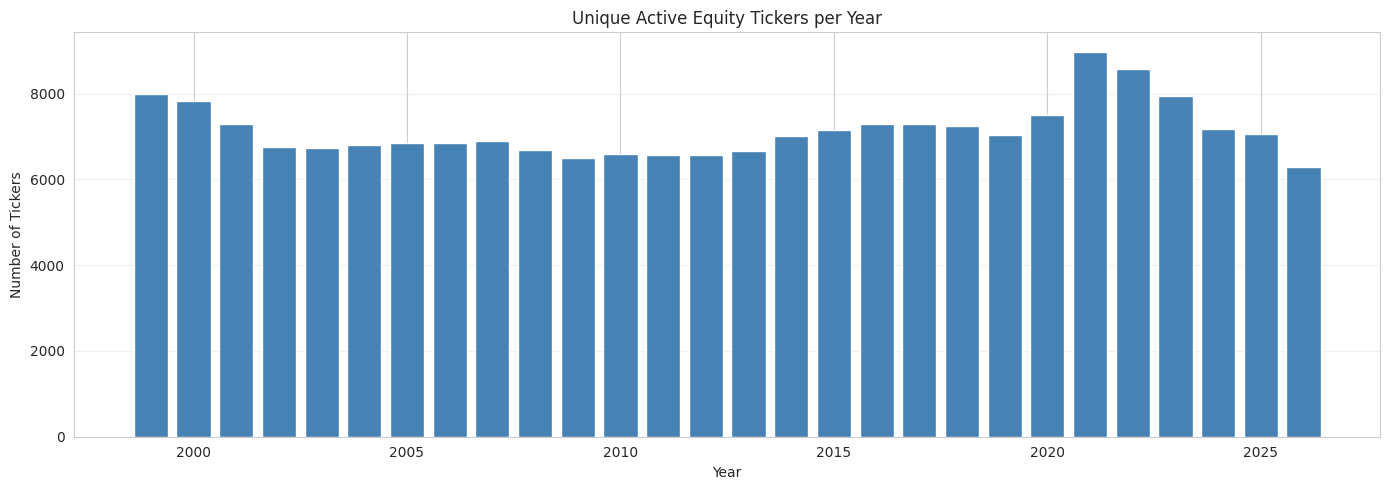


Peak Equity Size: 8,977 tickers in 2021
Smallest Equity Size: 6,280 tickers in 2026


In [8]:
print("Temporal Coverage of the Equities")

# Count unique active equity tickers per calendar year
# This shows how the investable pool grows and shrinks over time
equity_temporal = master_df[master_df['AssetClass'] == 'equity'].copy()
equity_temporal['Year'] = equity_temporal['Date'].dt.year

tickers_per_year = equity_temporal.groupby('Year')['Ticker'].nunique()

plt.figure(figsize=(14, 5))
plt.bar(tickers_per_year.index, tickers_per_year.values, color='steelblue', edgecolor='white')
plt.title("Unique Active Equity Tickers per Year")
plt.xlabel("Year")
plt.ylabel("Number of Tickers")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPeak Equity Size: {tickers_per_year.max():,} tickers in {tickers_per_year.idxmax()}")
print(f"Smallest Equity Size: {tickers_per_year.min():,} tickers in {tickers_per_year.idxmin()}")

# **Section 3 — Macro & Commodities**

MACRO & COMMODITIES OVERVIEW


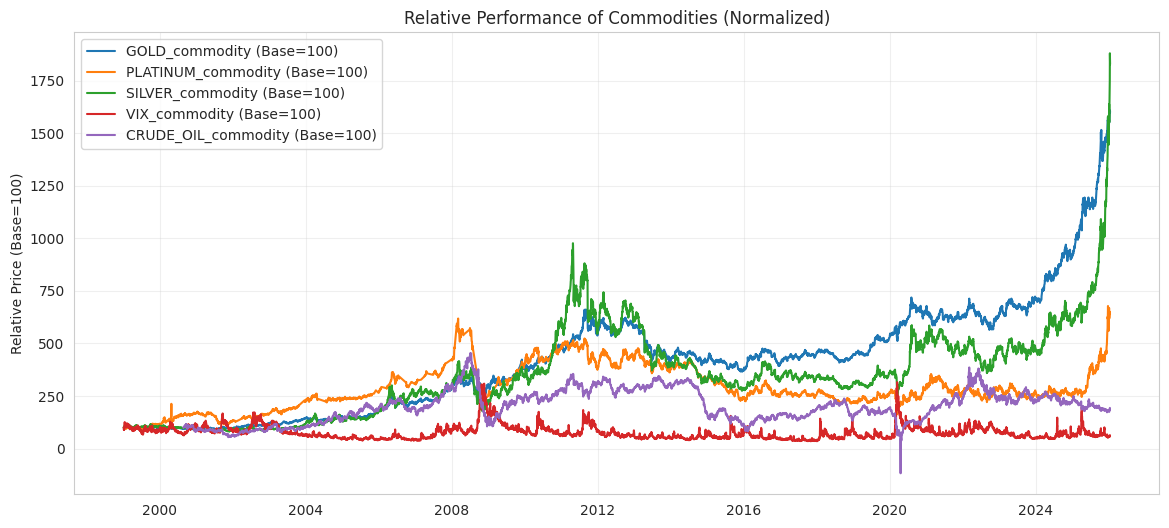

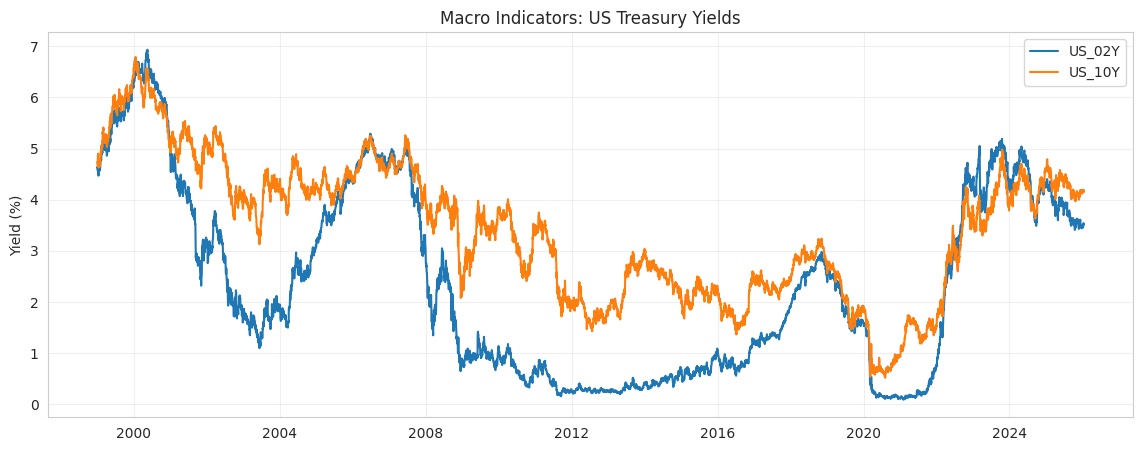


Commodities Statistics:
  - GOLD_commodity: 6,958 rows, Price Range: 252.35 to 4627.52
  - PLATINUM_commodity: 6,102 rows, Price Range: 343.30 to 2467.70
  - SILVER_commodity: 6,902 rows, Price Range: 4.06 to 93.27
  - VIX_commodity: 6,833 rows, Price Range: 9.14 to 82.69
  - CRUDE_OIL_commodity: 6,377 rows, Price Range: -37.63 to 145.29

Macro Statistics:
  - US_02Y: 6,762 rows, Range: 0.09% to 6.93%
  - US_10Y: 6,762 rows, Range: 0.52% to 6.79%
  - GER_10Y: 323 rows, Range: -0.65% to 5.54%
  - JPN_10Y: 323 rows, Range: -0.28% to 2.12%
  - UK_10Y: 323 rows, Range: 0.21% to 5.88%


In [9]:
print("MACRO & COMMODITIES OVERVIEW")

# Filter for plotting (using the 'AssetClass' column)
commodities_subset = master_df[master_df['AssetClass'] == 'commodity']
macro_subset = master_df[master_df['AssetClass'] == 'yield']

# Plot All Commodities
plt.figure(figsize=(14, 6))
for asset in commodities_subset['Ticker'].unique():
    subset = commodities_subset[commodities_subset['Ticker'] == asset]
    # Normalise to start at 100 for comparison
    # Use 'Close' as commodities might not have 'Adjusted_close' populated in all merges
    price_col = 'Close'
    first_val = subset[price_col].iloc[0] if len(subset) > 0 else 1
    normalised = (subset[price_col] / first_val) * 100
    plt.plot(subset['Date'], normalised, label=f"{asset} (Base=100)")

plt.title("Relative Performance of Commodities (Normalized)")
plt.ylabel("Relative Price (Base=100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot Key Macro Indicators (Yields)
plt.figure(figsize=(14, 5))
# Plot US 2Y vs US 10Y
for series in ['US_02Y', 'US_10Y']:
    subset = macro_subset[macro_subset['Ticker'] == series]
    plt.plot(subset['Date'], subset['Close'], label=series) # Yields use 'Close' column for value

plt.title("Macro Indicators: US Treasury Yields")
plt.ylabel("Yield (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Stats
print("\nCommodities Statistics:")
for asset in commodities_subset['Ticker'].unique():
    subset = commodities_subset[commodities_subset['Ticker'] == asset]
    print(f"  - {asset}: {len(subset):,} rows, Price Range: {subset['Close'].min():.2f} to {subset['Close'].max():.2f}")

print("\nMacro Statistics:")
for series in macro_subset['Ticker'].unique():
    subset = macro_subset[macro_subset['Ticker'] == series]
    print(f"  - {series}: {len(subset):,} rows, Range: {subset['Close'].min():.2f}% to {subset['Close'].max():.2f}%")

Yield Curve Decomposition: Level, Slope and Curvature


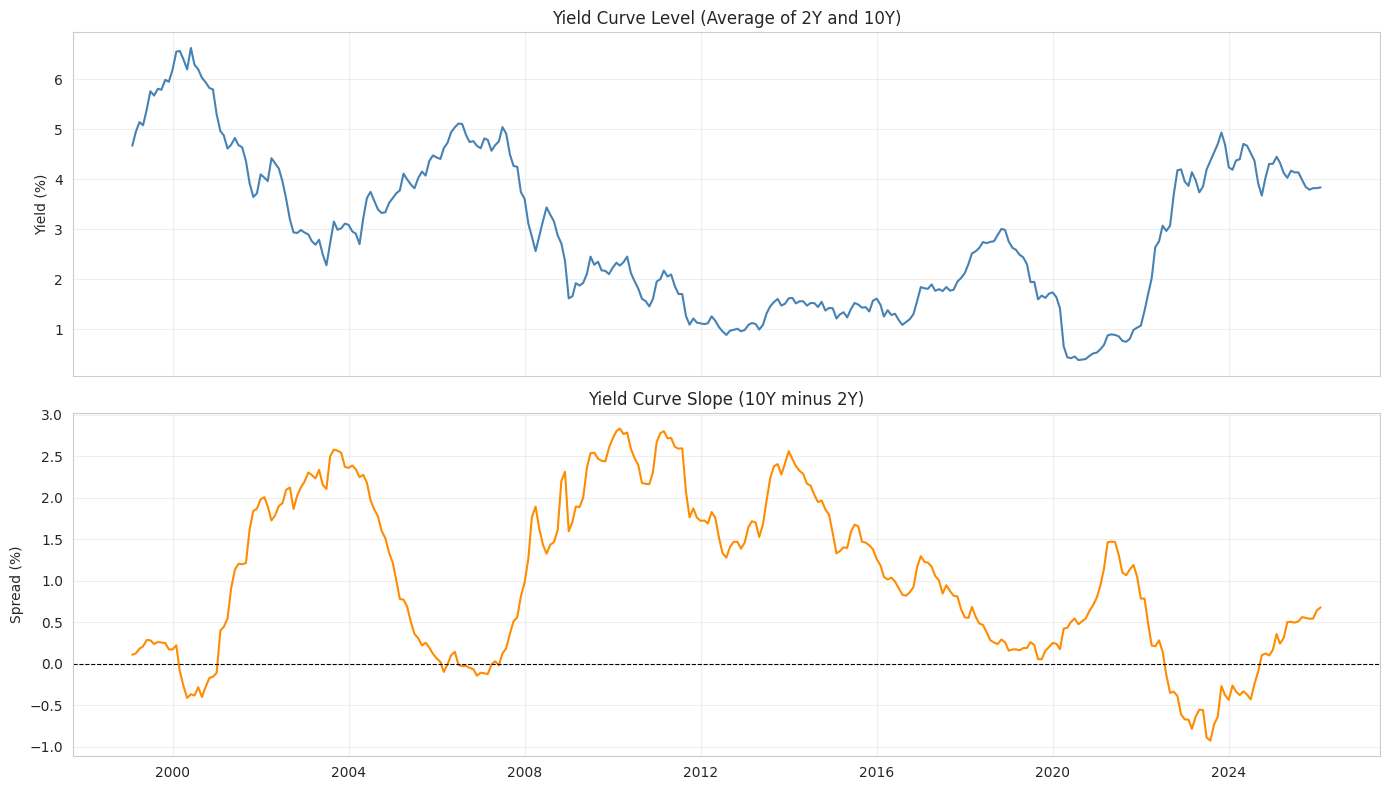


Yield Curve Summary:
  Mean Level:  2.90%
  Mean Slope:  1.03%
  Inverted Periods (Slope < 0): 50 months


In [10]:
print("Yield Curve Decomposition: Level, Slope and Curvature")

# Extract individual yield series from the macro subset
# Level = average of available yield tenors (proxy for the overall rate environment)
# Slope = 10Y minus 2Y (the classic spread; negative = inverted curve)
# Curvature = 2x5Y minus 2Y minus 10Y (bowing of the mid-section; requires 5Y data)

us_02y = macro_subset[macro_subset['Ticker'] == 'US_02Y'].set_index('Date')['Close'].sort_index()
us_10y = macro_subset[macro_subset['Ticker'] == 'US_10Y'].set_index('Date')['Close'].sort_index()

# Align on common dates
yield_df = pd.DataFrame({'US_02Y': us_02y, 'US_10Y': us_10y}).dropna()

# Compute decomposition components
yield_df['Level']  = yield_df[['US_02Y', 'US_10Y']].mean(axis=1)
yield_df['Slope']  = yield_df['US_10Y'] - yield_df['US_02Y']

# Resample to monthly for cleaner visualisation
yield_monthly = yield_df.resample('ME').mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(yield_monthly.index, yield_monthly['Level'], color='steelblue', linewidth=1.5)
axes[0].set_title("Yield Curve Level (Average of 2Y and 10Y)")
axes[0].set_ylabel("Yield (%)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(yield_monthly.index, yield_monthly['Slope'], color='darkorange', linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title("Yield Curve Slope (10Y minus 2Y)")
axes[1].set_ylabel("Spread (%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nYield Curve Summary:")
print(f"  Mean Level:  {yield_monthly['Level'].mean():.2f}%")
print(f"  Mean Slope:  {yield_monthly['Slope'].mean():.2f}%")
print(f"  Inverted Periods (Slope < 0): {(yield_monthly['Slope'] < 0).sum()} months")

Yield Curve Inversion Periods


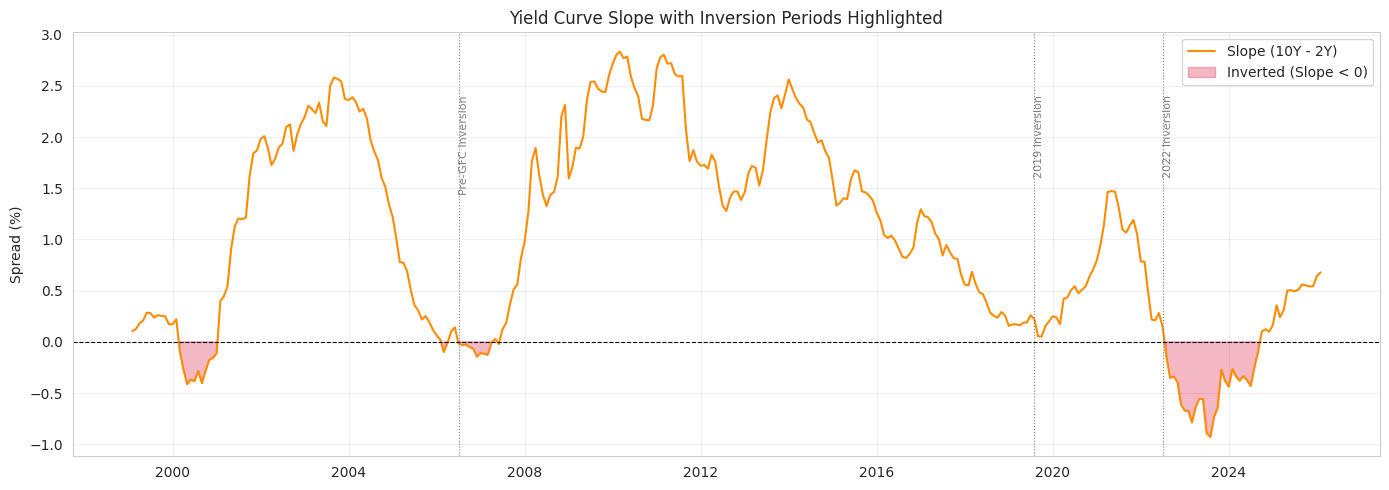


Total Months with Inverted Curve: 50
Proportion of History Inverted:   15.4%


In [11]:
print("Yield Curve Inversion Periods")

# Shade regions where the slope is negative (inverted curve)
# Inversions historically precede recessions and mark macro regime transitions
# These are the periods the quantum layer should learn to detect

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(yield_monthly.index, yield_monthly['Slope'], color='darkorange', linewidth=1.5, label='Slope (10Y - 2Y)')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Shade inversion periods
inversion = yield_monthly['Slope'] < 0
ax.fill_between(
    yield_monthly.index,
    yield_monthly['Slope'],
    0,
    where=inversion,
    color='crimson',
    alpha=0.3,
    label='Inverted (Slope < 0)'
)

# Annotate known macro events
known_events = {
    '2006-07': 'Pre-GFC Inversion',
    '2019-08': '2019 Inversion',
    '2022-07': '2022 Inversion',
}
for date_str, label in known_events.items():
    try:
        ax.axvline(pd.Timestamp(date_str), color='grey', linewidth=0.8, linestyle=':')
        ax.text(pd.Timestamp(date_str), yield_monthly['Slope'].max() * 0.85, label,
                fontsize=8, rotation=90, color='grey', va='top')
    except Exception:
        pass

ax.set_title("Yield Curve Slope with Inversion Periods Highlighted")
ax.set_ylabel("Spread (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

total_inverted = inversion.sum()
print(f"\nTotal Months with Inverted Curve: {total_inverted}")
print(f"Proportion of History Inverted:   {total_inverted / len(yield_monthly):.1%}")

# **Section 4 — Data Quality**

DATA QUALITY CHECK

Missing Values by Column:
Ticker                 881
Open                 14493
High                 14493
Low                  14493
Adjusted_close       40832
Volume               14493
Name                 48047
Country              33172
Exchange             47665
Currency             47665
Type                 47665
Isin              14604429
Frequency         43993071
dtype: int64

Rows with Close Price <= 0: 6,830
Rows with Zero Volume: 3,193,443 (7.26%)


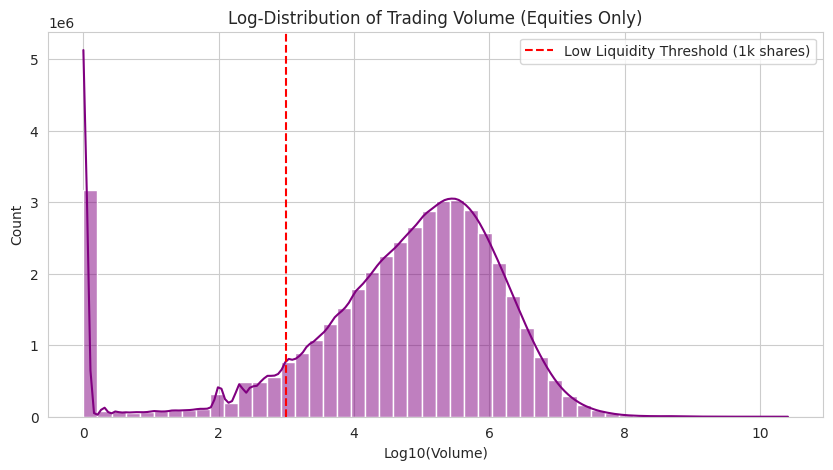

In [12]:
print("DATA QUALITY CHECK")

# Check for Missing Values
missing = master_df.isnull().sum()
print("\nMissing Values by Column:")
print(missing[missing > 0])

# Check for "Zero" or Negative Prices (Fatal for Log Returns)
# We check 'Close' as it is common across all assets
zeros = (master_df['Close'] <= 0).sum()
print(f"\nRows with Close Price <= 0: {zeros:,}")

# Check for Zero Volume (Illiquidity)
# Note: Macro yields and some commodities might naturally have 0 or NaN volume
zero_vol = (master_df['Volume'] == 0).sum()
pct_zero_vol = (zero_vol / len(master_df)) * 100
print(f"Rows with Zero Volume: {zero_vol:,} ({pct_zero_vol:.2f}%)")

# Visualisation: Distribution of Volume (Log Scale)
# Filter for equities only for this plot as yields don't have trading volume
equities_only = master_df[master_df['AssetClass'] == 'equity']

plt.figure(figsize=(10, 5))
# Add +1 to volume to avoid log(0) error
sns.histplot(np.log10(equities_only['Volume'].fillna(0) + 1), bins=50, kde=True, color='purple')
plt.title("Log-Distribution of Trading Volume (Equities Only)")
plt.xlabel("Log10(Volume)")
plt.axvline(x=np.log10(1000), color='r', linestyle='--', label='Low Liquidity Threshold (1k shares)')
plt.legend()
plt.show()

Price Scale by Asset Class

Equity:
  Median: 13.4300
  Min:    0.0000
  Max:    1000000.0000

Yield:
  Median: 2.7600
  Min:    -0.6491
  Max:    6.9300

Commodity:
  Median: 61.1000
  Min:    -37.6300
  Max:    4627.5200


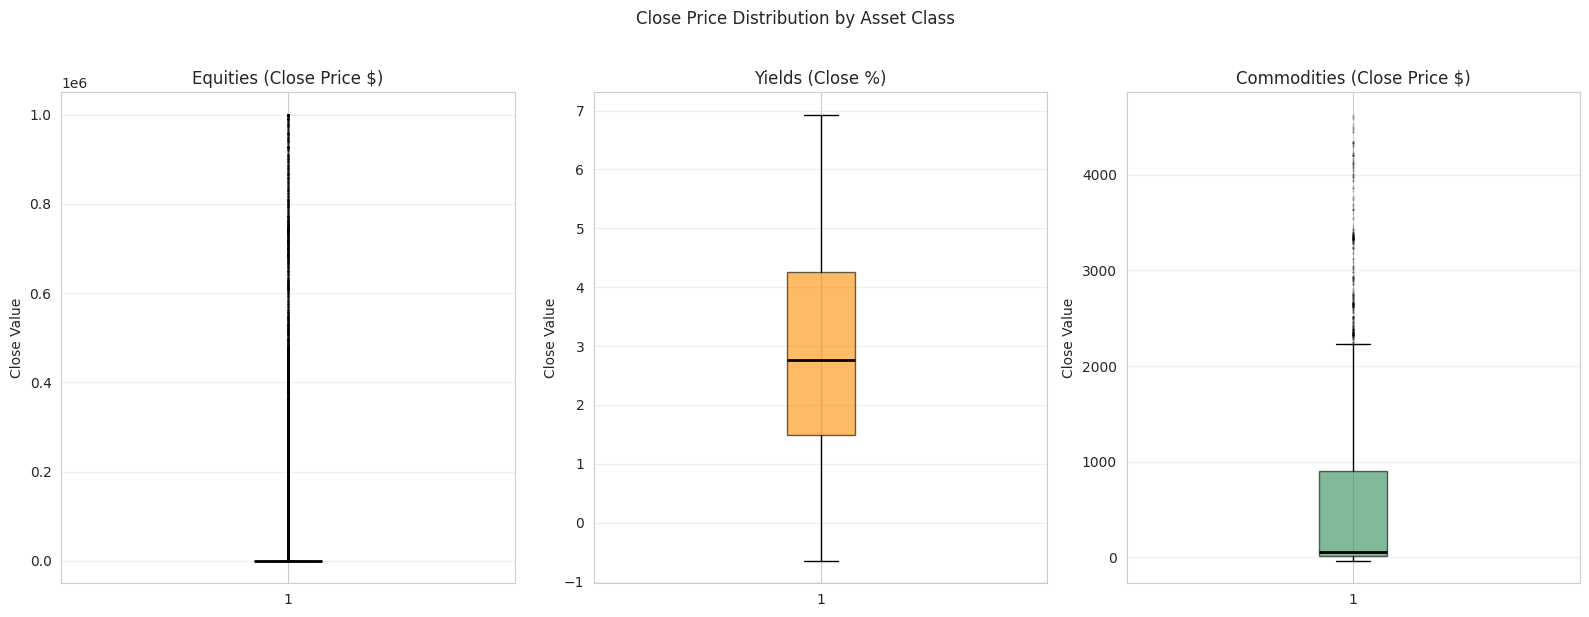

In [13]:
print("Price Scale by Asset Class")

# Boxplot of Close price per asset class
# Equities range from sub-penny to thousands, yields cluster between 0-15%,
# commodities sit between - understanding these scales explains why
# robust normalisation is non-trivial across the merged master dataset

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

asset_classes = ['equity', 'yield', 'commodity']
colours      = ['steelblue', 'darkorange', 'seagreen']
titles       = ['Equities (Close Price $)', 'Yields (Close %)', 'Commodities (Close Price $)']

for ax, a_class, colour, title in zip(axes, asset_classes, colours, titles):
    subset = master_df[master_df['AssetClass'] == a_class]['Close'].dropna()

    ax.boxplot(subset, patch_artist=True,
               boxprops=dict(facecolor=colour, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='.', markersize=1, alpha=0.2))

    ax.set_title(title)
    ax.set_ylabel("Close Value")
    ax.grid(axis='y', alpha=0.3)

    print(f"\n{a_class.capitalize()}:")
    print(f"  Median: {subset.median():.4f}")
    print(f"  Min:    {subset.min():.4f}")
    print(f"  Max:    {subset.max():.4f}")

plt.suptitle("Close Price Distribution by Asset Class", y=1.02)
plt.tight_layout()
plt.show()

In [14]:
print("MISSING DATA FORENSICS")


print("\nCompleteness within Asset Classes (No NaNs in that class's expected columns):")

for a_class in master_df['AssetClass'].unique():
    # Filter for the class
    class_df = master_df[master_df['AssetClass'] == a_class]

    # Identify columns that are NOT entirely NaN for this class
    active_cols = class_df.columns[class_df.notna().any()].tolist()

    # Count perfect rows within those active columns
    class_perfect = (class_df[active_cols].isnull().sum(axis=1) == 0).sum()
    print(f"{a_class:<12}: {class_perfect:,} perfect rows ({class_perfect/len(class_df):.1%})")

# Sequential Gap Analysis (The "Data Holes")
print("\nAnalysing Equity Data Gaps")

def count_internal_gaps(group):
    first = group.first_valid_index()
    last = group.last_valid_index()
    if first is None or last is None:
        return 0
    active_life = group.loc[first:last]
    return active_life.isnull().sum()

# We look at equities specifically
gap_stats = master_df[master_df['AssetClass'] == 'equity'].groupby('Ticker', observed=True)['Close'].apply(count_internal_gaps)
tickers_with_gaps = gap_stats[gap_stats > 0]

print("\nGap Analysis Stats:")
print(f"Total Tickers Analyzed: {len(gap_stats):,}")
print(f"Tickers with INTERNAL missing data (Holes): {len(tickers_with_gaps):,} ({len(tickers_with_gaps)/len(gap_stats):.1%})")

# ONLY run these if we actually found gaps, otherwise print a success message
if len(tickers_with_gaps) > 0:
    print(f"Avg Missing Days per 'Gapped' Ticker: {tickers_with_gaps.mean():.1f} days")
    print(f"Worst Offender: {tickers_with_gaps.idxmax()} ({tickers_with_gaps.max():,} missing days)")

    # Visualise
    plt.figure(figsize=(10, 5))
    sns.histplot(tickers_with_gaps, bins=50, color='salmon', log_scale=(False, True))
    plt.title("Distribution of Internal Data Gaps (Log Scale Y)")
    plt.xlabel("Number of Missing Days (during active listing)")
    plt.ylabel("Count of Tickers")
    plt.show()
else:
    print("DATA INTEGRITY VERIFIED: No internal gaps found in the equity price series.")

# Global Null Distribution (Column-wise)
print("\nGlobal Column-wise Nulls (Total rows: {:,}):".format(len(master_df)))
null_counts = master_df.isnull().sum()
for col, count in null_counts.items():
    if count > 0:
        print(f"  - {col:<18}: {count:,} nulls ({count/len(master_df):.1%})")

MISSING DATA FORENSICS

Completeness within Asset Classes (No NaNs in that class's expected columns):
commodity   : 6,833 perfect rows (20.6%)
equity      : 29,402,254 perfect rows (66.9%)
yield       : 14,493 perfect rows (100.0%)

Analysing Equity Data Gaps

Gap Analysis Stats:
Total Tickers Analyzed: 20,758
Tickers with INTERNAL missing data (Holes): 0 (0.0%)
DATA INTEGRITY VERIFIED: No internal gaps found in the equity price series.

Global Column-wise Nulls (Total rows: 44,007,564):
  - Ticker            : 881 nulls (0.0%)
  - Open              : 14,493 nulls (0.0%)
  - High              : 14,493 nulls (0.0%)
  - Low               : 14,493 nulls (0.0%)
  - Adjusted_close    : 40,832 nulls (0.1%)
  - Volume            : 14,493 nulls (0.0%)
  - Name              : 48,047 nulls (0.1%)
  - Country           : 33,172 nulls (0.1%)
  - Exchange          : 47,665 nulls (0.1%)
  - Currency          : 47,665 nulls (0.1%)
  - Type              : 47,665 nulls (0.1%)
  - Isin              : 14

# **Section 5 — Equity Pool**

CALCULATING TICKER-LEVEL AGGREGATES (Mean Price vs. Volatility)


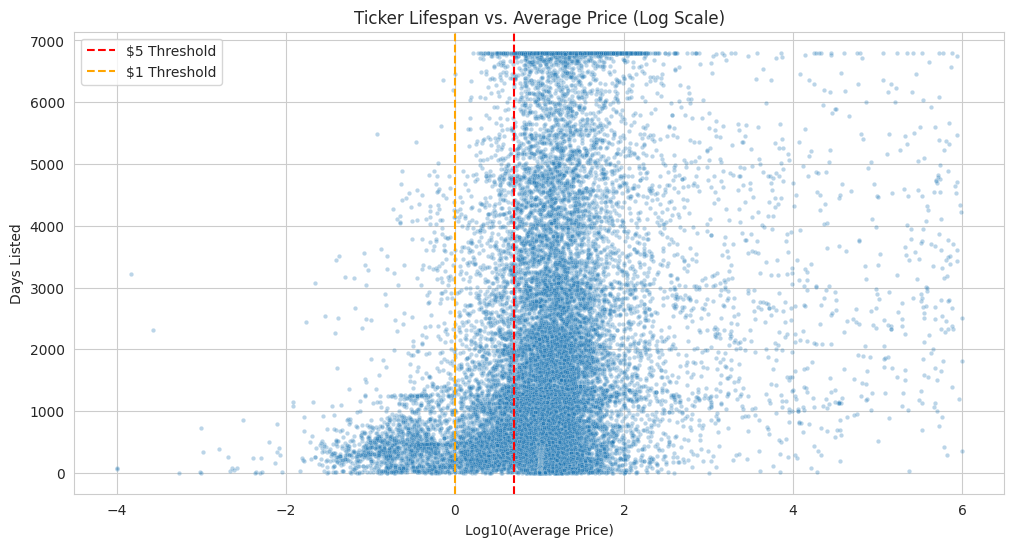


Penny Stock Population (Equities Only)
Total Equity Tickers: 20,758
Tickers < $5: 4,710 (22.7%)
Tickers < $1: 1,765 (8.5%)


In [15]:
print("CALCULATING TICKER-LEVEL AGGREGATES (Mean Price vs. Volatility)")

# We focus on Equities for the Penny Stock analysis
# (Yields like 'US_10Y' have a value of 4.0 but are not penny stocks)
equities_subset = master_df[master_df['AssetClass'] == 'equity'].copy()

# Use Adjusted_close for equities if available, else Close
price_col = 'Adjusted_close'

# Group by Ticker
ticker_stats = equities_subset.groupby('Ticker', observed=True).agg({
    price_col: ['mean', 'min', 'max'],
    'Volume': 'mean',
    'Date': ['min', 'max', 'count']
})
ticker_stats.columns = ['mean_price', 'min_price', 'max_price', 'mean_vol', 'start_date', 'end_date', 'days_count']
ticker_stats = ticker_stats.reset_index()

# Calculate log price for scatter plot
ticker_stats['log_price'] = np.log10(ticker_stats['mean_price'] + 1e-9)

# Scatter Plot: Price vs. Count of Days
plt.figure(figsize=(12, 6))
sns.scatterplot(data=ticker_stats, x='log_price', y='days_count', alpha=0.3, s=10)
plt.title("Ticker Lifespan vs. Average Price (Log Scale)")
plt.xlabel("Log10(Average Price)")
plt.ylabel("Days Listed")
plt.axvline(x=np.log10(5), color='red', linestyle='--', label='$5 Threshold')
plt.axvline(x=np.log10(1), color='orange', linestyle='--', label='$1 Threshold')
plt.legend()
plt.show()

# STATS
penny_counts = (ticker_stats['mean_price'] < 5).sum()
sub_penny_counts = (ticker_stats['mean_price'] < 1).sum()
print("\nPenny Stock Population (Equities Only)")
print(f"Total Equity Tickers: {len(ticker_stats):,}")
print(f"Tickers < $5: {penny_counts:,} ({(penny_counts/len(ticker_stats))*100:.1f}%)")
print(f"Tickers < $1: {sub_penny_counts:,} ({(sub_penny_counts/len(ticker_stats))*100:.1f}%)")

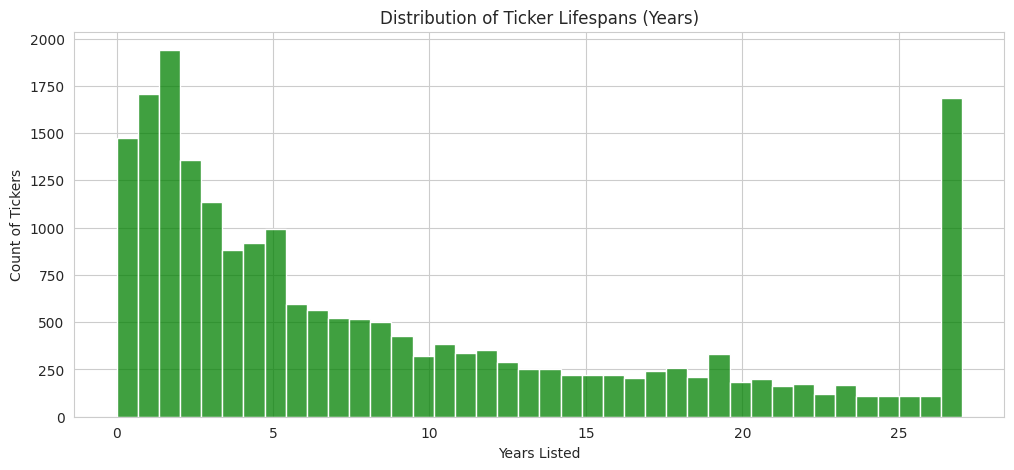


Survivorship Statistics
Avg Lifespan: 8.8 years
Median Lifespan: 5.4 years
Short-Lived (<2 years): 5,029 tickers
Long-Lived (>10 years): 6,966 tickers
Correlation (Price vs. Lifespan): 0.0637 (Do cheaper stocks die faster?)


In [16]:
# Calculate duration in years
ticker_stats['years_listed'] = (ticker_stats['end_date'] - ticker_stats['start_date']).dt.days / 365.25

# Histogram of Lifespans
plt.figure(figsize=(12, 5))
sns.histplot(ticker_stats['years_listed'], bins=40, kde=False, color='green')
plt.title("Distribution of Ticker Lifespans (Years)")
plt.xlabel("Years Listed")
plt.ylabel("Count of Tickers")
plt.show()

# "Ghosts" Stats
short_lived = ticker_stats[ticker_stats['years_listed'] < 2]
long_lived = ticker_stats[ticker_stats['years_listed'] > 10]

print("\nSurvivorship Statistics")
print(f"Avg Lifespan: {ticker_stats['years_listed'].mean():.1f} years")
print(f"Median Lifespan: {ticker_stats['years_listed'].median():.1f} years")
print(f"Short-Lived (<2 years): {len(short_lived):,} tickers")
print(f"Long-Lived (>10 years): {len(long_lived):,} tickers")

# Correlation between Price and Lifespan
corr = ticker_stats['mean_price'].corr(ticker_stats['years_listed'])
print(f"Correlation (Price vs. Lifespan): {corr:.4f} (Do cheaper stocks die faster?)")

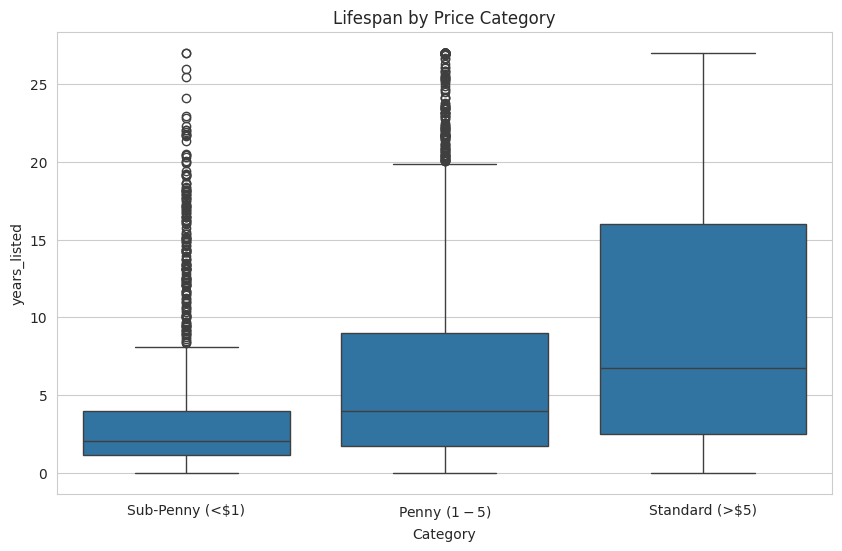


Detailed Comparison by Category
                mean_price years_listed                   mean_vol            
                     count         mean median    std         mean      median
Category                                                                      
Penny ($1-$5)         2945       6.6000 3.9600 6.8300  413071.4375  74075.6562
Standard (>$5)       16048       9.8400 6.7600 8.6800  982676.6250 161044.1719
Sub-Penny (<$1)       1765       3.4900 2.0700 4.2600 1736554.8750  31637.8906


In [17]:
# Create Categories
conditions = [
    (ticker_stats['mean_price'] < 1),
    (ticker_stats['mean_price'] >= 1) & (ticker_stats['mean_price'] < 5),
    (ticker_stats['mean_price'] >= 5)
]
choices = ['Sub-Penny (<$1)', 'Penny ($1-$5)', 'Standard (>$5)']

# Fix for mixed types: Ensure choices are compatible
ticker_stats['Category'] = np.select(conditions, choices, default='Unknown')

# Boxplot of Lifespan by Category
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='years_listed', data=ticker_stats, order=['Sub-Penny (<$1)', 'Penny ($1-$5)', 'Standard (>$5)'])
plt.title("Lifespan by Price Category")
plt.show()

# Detailed Stats Table
groupby_stats = ticker_stats.groupby('Category', observed=True).agg({
    'mean_price': 'count',
    'years_listed': ['mean', 'median', 'std'],
    'mean_vol': ['mean', 'median'] # Volume
}).round(2)

print("\nDetailed Comparison by Category")
print(groupby_stats)

# **Section 6 — Liquidity & Volume**

LIQUIDITY & DATA GAP ANALYSIS (Equities Only)


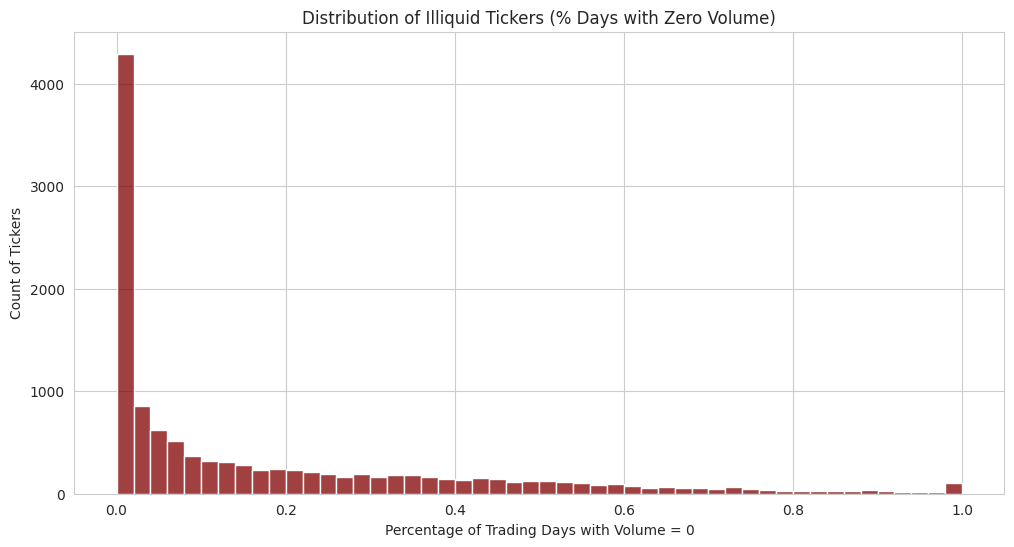


'Ghost' Tickers (>50% days with zero volume): 1383
Sample Ghosts: ['ABF', 'ABR_old', 'ACS', 'AGRI_old1', 'AICIQ', 'AIJ', 'ALCI', 'AOG', 'AORGB', 'APCFY']

Volatility Comparison (Price Std Dev):
  - Liquid Stocks Avg:   $14.73
  - Illiquid/Ghost Avg:  $453.21


In [18]:
print("LIQUIDITY & DATA GAP ANALYSIS (Equities Only)")

# Filter for Equities Only
equities_only = master_df[master_df['AssetClass'] == 'equity']

# Zero Volume Analysis
# Count how many days each ticker had 0 volume
zero_vol_stats = equities_only[equities_only['Volume'] == 0].groupby('Ticker', observed=True).size()
total_days = equities_only.groupby('Ticker', observed=True).size()

illiquidity_ratio = (zero_vol_stats / total_days).fillna(0)
illiquidity_ratio.name = "pct_zero_volume"

# Plotting Illiquidity
plt.figure(figsize=(12, 6))
sns.histplot(illiquidity_ratio[illiquidity_ratio > 0], bins=50, color='maroon')
plt.title("Distribution of Illiquid Tickers (% Days with Zero Volume)")
plt.xlabel("Percentage of Trading Days with Volume = 0")
plt.ylabel("Count of Tickers")
plt.show()

# List the "Ghost" Tickers (High Illiquidity)
ghosts = illiquidity_ratio[illiquidity_ratio > 0.5].index.tolist()
print(f"\n'Ghost' Tickers (>50% days with zero volume): {len(ghosts)}")
print(f"Sample Ghosts: {ghosts[:10]}")

# Impact on Analysis
# Compare Volatility of Liquid vs Illiquid stocks
liquid_tickers = illiquidity_ratio[illiquidity_ratio < 0.05].index
illiquid_tickers = illiquidity_ratio[illiquidity_ratio > 0.3].index

# Calculate volatility for a sample (std dev of price)
liquid_sample = equities_only[equities_only['Ticker'].isin(liquid_tickers[:100])].groupby('Ticker', observed=True)['Close'].std()
illiquid_sample = equities_only[equities_only['Ticker'].isin(illiquid_tickers[:100])].groupby('Ticker', observed=True)['Close'].std()

print("\nVolatility Comparison (Price Std Dev):")
print(f"  - Liquid Stocks Avg:   ${liquid_sample.mean():.2f}")
print(f"  - Illiquid/Ghost Avg:  ${illiquid_sample.mean():.2f}")

VOLUME ANOMALY DETECTION

Global Median Volume: 118,234 shares

Volume Extremes:
Massive Spikes (>100x median): 662,819 rows
Liquidity Traps (<100 shares): 712,294 rows


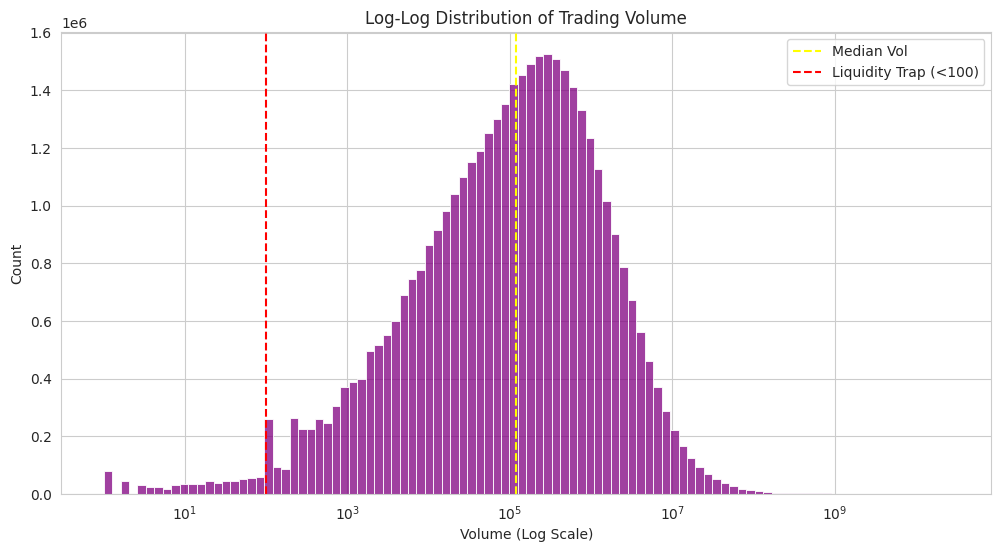

In [19]:
print("VOLUME ANOMALY DETECTION")

# We look at Equities only
equity_mask = master_df['AssetClass'] == 'equity'
# Filter to positive volume to avoid log(0)
vol_data = master_df.loc[equity_mask & (master_df['Volume'] > 0), 'Volume']

# 1. The "100x" Club
# How many records show volume > 100x the median volume?
median_vol = vol_data.median()
huge_vol_spikes = (vol_data > (median_vol * 100)).sum()

# 2. The "Dead" Club
# Volume < 100 shares (Liquidity trap)
low_vol_days = (vol_data < 100).sum()

print(f"\nGlobal Median Volume: {median_vol:,.0f} shares")
print("\nVolume Extremes:")
print(f"Massive Spikes (>100x median): {huge_vol_spikes:,} rows")
print(f"Liquidity Traps (<100 shares): {low_vol_days:,} rows")

# 3. Visualising the "Tails" of Liquidity
plt.figure(figsize=(12, 6))
# Log-Log plot is best for volume
sns.histplot(vol_data, bins=100, log_scale=True, color='purple')
plt.axvline(median_vol, color='yellow', linestyle='--', label='Median Vol')
plt.axvline(100, color='red', linestyle='--', label='Liquidity Trap (<100)')
plt.title("Log-Log Distribution of Trading Volume")
plt.xlabel("Volume (Log Scale)")
plt.legend()
plt.show()

# **Section 7 — Return Distributions**

STATISTICAL OUTLIER ANALYSIS

Outlier Statistics (Based on Daily Returns):
Total Return Data Points: 43,979,596
Z-Score > 3 (Rare Events): 1,231 (0.00%)
Z-Score > 6 (Extreme/Black Swan): 900 (0.00%)
IQR Outliers (Robust Method): 5,678,710 (12.91%)

Extreme Value Check:
Max Single Day Return: 2556224400.00% (Likely a Penny Stock or Data Error)
Min Single Day Return: -900.00% (Crash or Bankruptcy)


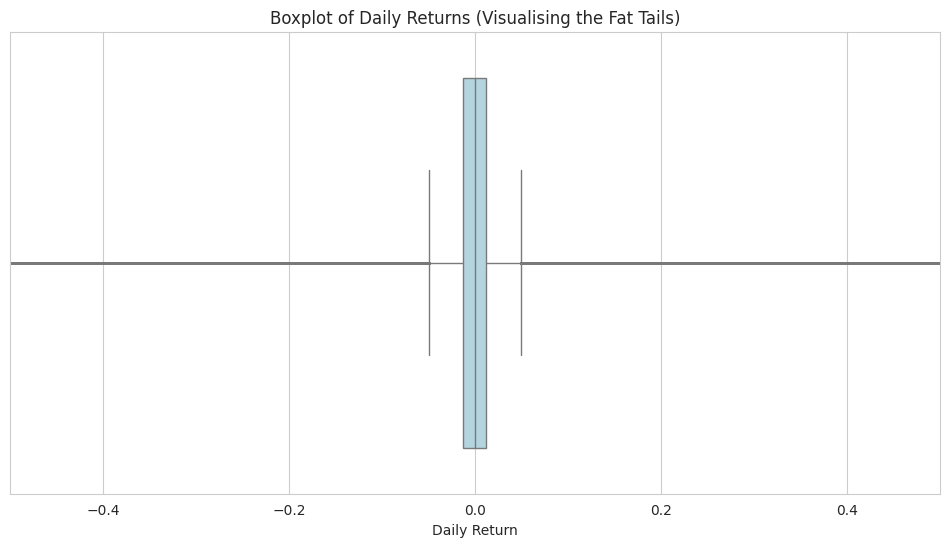

In [20]:
print("STATISTICAL OUTLIER ANALYSIS")

# Calculate Daily Returns for the whole dataset (fastest way)
# We need returns because Price Z-scores are meaningless (prices drift), but Returns should be stationary.
master_df['Returns'] = master_df.groupby('Ticker')['Close'].pct_change()

# Filter out infinite/NaN returns generated by the calculation
valid_returns = master_df['Returns'].dropna()
valid_returns = valid_returns[np.isfinite(valid_returns)]

# Z-Score Method (Gaussian Assumption)
# Z > 3 is "Rare" (99.7%), Z > 6 is "Black Swan"
z_scores = stats.zscore(valid_returns)
outliers_3sigma = (np.abs(z_scores) > 3).sum()
outliers_6sigma = (np.abs(z_scores) > 6).sum()

# IQR Method (Robust to non-normal distributions - Better for Finance)
Q1 = valid_returns.quantile(0.25)
Q3 = valid_returns.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outliers = ((valid_returns < lower_bound) | (valid_returns > upper_bound)).sum()

print("\nOutlier Statistics (Based on Daily Returns):")
print(f"Total Return Data Points: {len(valid_returns):,}")
print(f"Z-Score > 3 (Rare Events): {outliers_3sigma:,} ({outliers_3sigma/len(valid_returns):.2%})")
print(f"Z-Score > 6 (Extreme/Black Swan): {outliers_6sigma:,} ({outliers_6sigma/len(valid_returns):.2%})")
print(f"IQR Outliers (Robust Method): {iqr_outliers:,} ({iqr_outliers/len(valid_returns):.2%})")

print("\nExtreme Value Check:")
print(f"Max Single Day Return: {valid_returns.max():.2%} (Likely a Penny Stock or Data Error)")
print(f"Min Single Day Return: {valid_returns.min():.2%} (Crash or Bankruptcy)")

# Visualise the Tails (Zoomed in on outliers)
plt.figure(figsize=(12, 6))
sns.boxplot(x=valid_returns, color='lightblue', fliersize=1) # fliersize=1 makes dots small
plt.title("Boxplot of Daily Returns (Visualising the Fat Tails)")
plt.xlabel("Daily Return")
plt.xlim(-0.5, 0.5) # Zoom in to +/- 50% returns to see the density
plt.show()

# Clean up memory
del valid_returns
master_df.drop(columns=['Returns'], inplace=True)

DISTRIBUTION ANALYSIS (Gaussian vs Real)


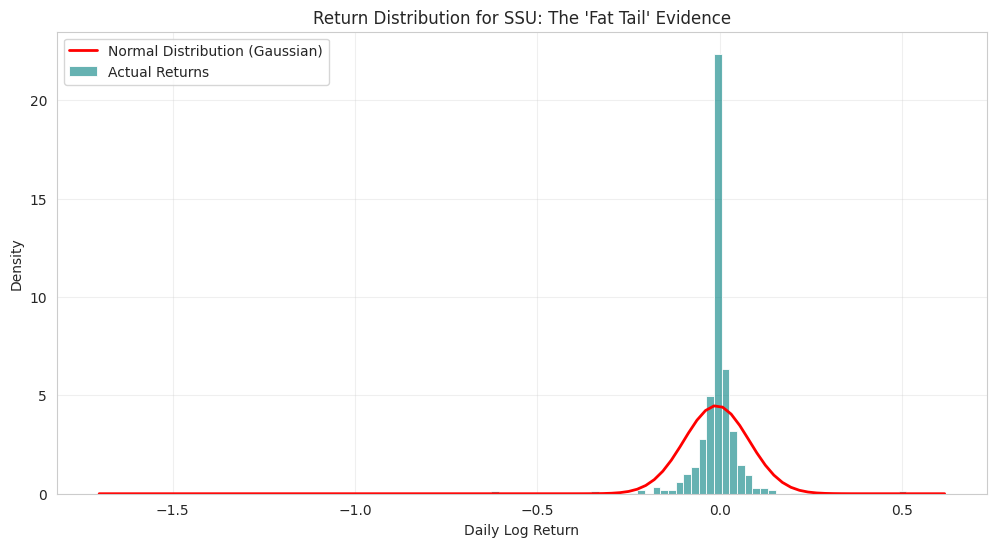

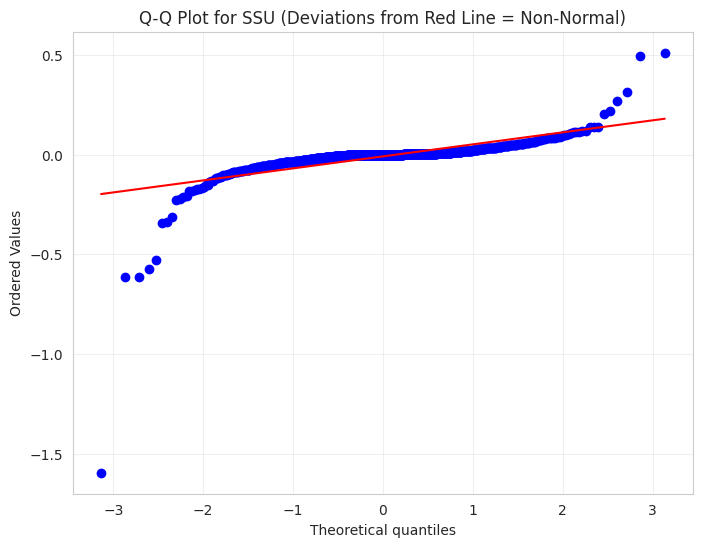


Distribution Stats for SSU:
Kurtosis: 134.0070 (Normal = 0.0. >0 implies 'Fat Tails')
Skewness: -7.9788 (Normal = 0.0)

CONCLUSION: Highly Leptokurtic. Geometric/Quantum methods justified.


In [21]:
print("DISTRIBUTION ANALYSIS (Gaussian vs Real)")

# Select a random sample of returns from non-penny equities in Master DF
safe_equities = master_df[(master_df['AssetClass']=='equity') & (master_df['Close'] > 10)]
safe_tickers = safe_equities['Ticker'].unique()

if len(safe_tickers) > 0:
    sample_ticker = np.random.choice(safe_tickers)
    ticker_data = master_df[master_df['Ticker'] == sample_ticker].sort_values('Date')

    # Calculate Log Returns
    log_returns = np.log(ticker_data['Close'] / ticker_data['Close'].shift(1)).dropna()

    # Histogram vs Normal Curve
    plt.figure(figsize=(12, 6))
    sns.histplot(log_returns, bins=100, kde=False, stat='density', label='Actual Returns', color='teal', alpha=0.6)

    # Overlay Normal Distribution
    mu, std = norm.fit(log_returns)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'r', linewidth=2, label='Normal Distribution (Gaussian)')

    plt.title(f"Return Distribution for {sample_ticker}: The 'Fat Tail' Evidence")
    plt.xlabel("Daily Log Return")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Q-Q Plot
    plt.figure(figsize=(8, 6))
    stats.probplot(log_returns, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot for {sample_ticker} (Deviations from Red Line = Non-Normal)")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Stats
    k = kurtosis(log_returns)
    s = skew(log_returns)

    print(f"\nDistribution Stats for {sample_ticker}:")
    print(f"Kurtosis: {k:.4f} (Normal = 0.0. >0 implies 'Fat Tails')")
    print(f"Skewness: {s:.4f} (Normal = 0.0)")
    if k > 3.0:
        print("\nCONCLUSION: Highly Leptokurtic. Geometric/Quantum methods justified.")
    else:
        print("\nCONCLUSION: Relatively Normal distribution.")
else:
    print("Not enough high-priced stocks found for sampling.")

Full Log Return Distribution


/venv/main/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)



Full Return Summary:
  Observations:  43,930,380
  Mean:          -0.000423
  Std Dev:       0.189976
  Kurtosis:      2042.5358 (Normal = 0.0, higher implies fatter tails)
  Skewness:      0.1676 (Normal = 0.0, negative implies downside asymmetry)


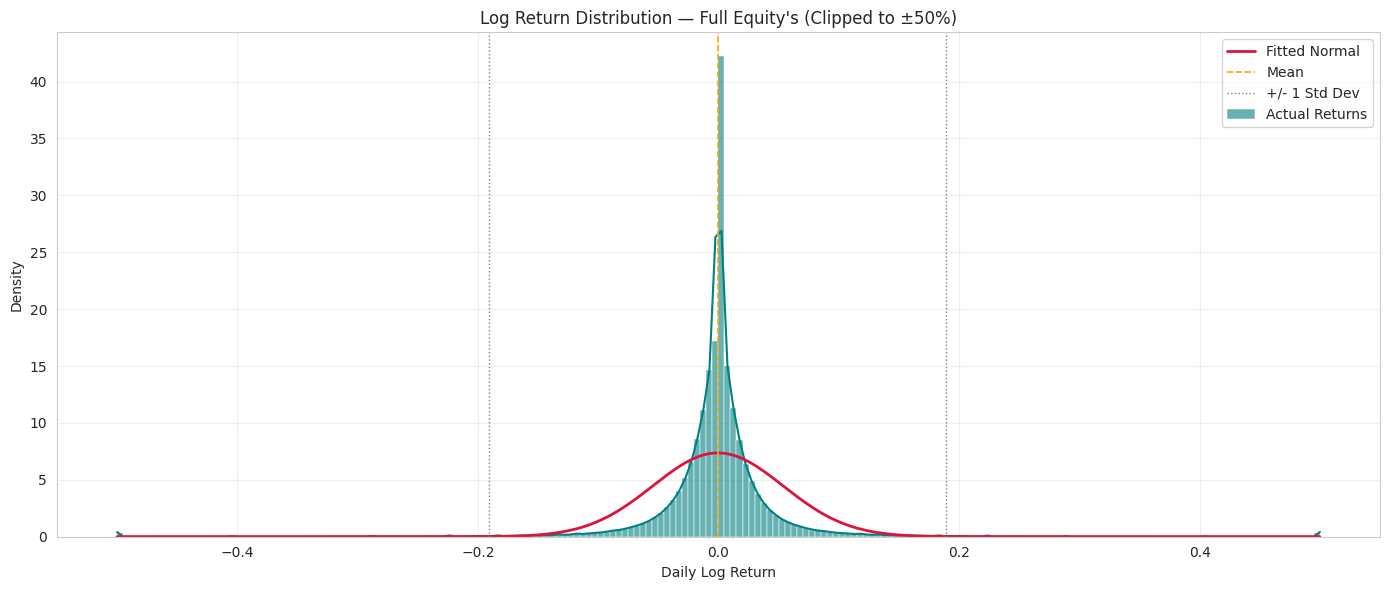

In [22]:
print("Full Log Return Distribution")

# Use Adjusted_close where valid, fall back to Close for assets without adjustment
# This ensures equities use corporate-action-adjusted prices whilst commodities
# and yields fall back cleanly to their Close value
equity_returns_df = master_df[master_df['AssetClass'] == 'equity'].copy()

equity_returns_df['price'] = np.where(
    equity_returns_df['Adjusted_close'].notna() & (equity_returns_df['Adjusted_close'] > 0),
    equity_returns_df['Adjusted_close'],
    equity_returns_df['Close']
)

# Compute log return per ticker using the resolved price column
equity_returns_df = equity_returns_df.sort_values(['Ticker', 'Date'])
equity_returns_df['log_return_1d'] = (
    equity_returns_df.groupby('Ticker', observed=True)['price']
    .transform(lambda x: np.log(x / x.shift(1)))
)

# Drop nulls and infinite values produced at the start of each ticker's series
log_ret_clean = equity_returns_df['log_return_1d'].replace([np.inf, -np.inf], np.nan).dropna()

# Summary statistics
k_val = kurtosis(log_ret_clean)
s_val = skew(log_ret_clean)

print(f"\nFull Return Summary:")
print(f"  Observations:  {len(log_ret_clean):,}")
print(f"  Mean:          {log_ret_clean.mean():.6f}")
print(f"  Std Dev:       {log_ret_clean.std():.6f}")
print(f"  Kurtosis:      {k_val:.4f} (Normal = 0.0, higher implies fatter tails)")
print(f"  Skewness:      {s_val:.4f} (Normal = 0.0, negative implies downside asymmetry)")

# Clip for plotting to avoid extreme penny stock returns dominating the axis
plot_returns = log_ret_clean.clip(-0.5, 0.5)

fig, ax = plt.subplots(figsize=(14, 6))

sns.histplot(plot_returns, bins=200, kde=True, stat='density',
             color='teal', alpha=0.6, ax=ax, label='Actual Returns')

# Overlay fitted normal distribution for comparison
mu, std = norm.fit(plot_returns)
x = np.linspace(-0.5, 0.5, 300)
ax.plot(x, norm.pdf(x, mu, std), color='crimson', linewidth=2, label='Fitted Normal')

ax.axvline(log_ret_clean.mean(), color='orange', linestyle='--', linewidth=1.2, label='Mean')
ax.axvline(log_ret_clean.mean() + log_ret_clean.std(), color='grey',
           linestyle=':', linewidth=1, label='+/- 1 Std Dev')
ax.axvline(log_ret_clean.mean() - log_ret_clean.std(), color='grey', linestyle=':', linewidth=1)

ax.set_title("Log Return Distribution — Full Equity's (Clipped to ±50%)")
ax.set_xlabel("Daily Log Return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Log Return Distribution by Year


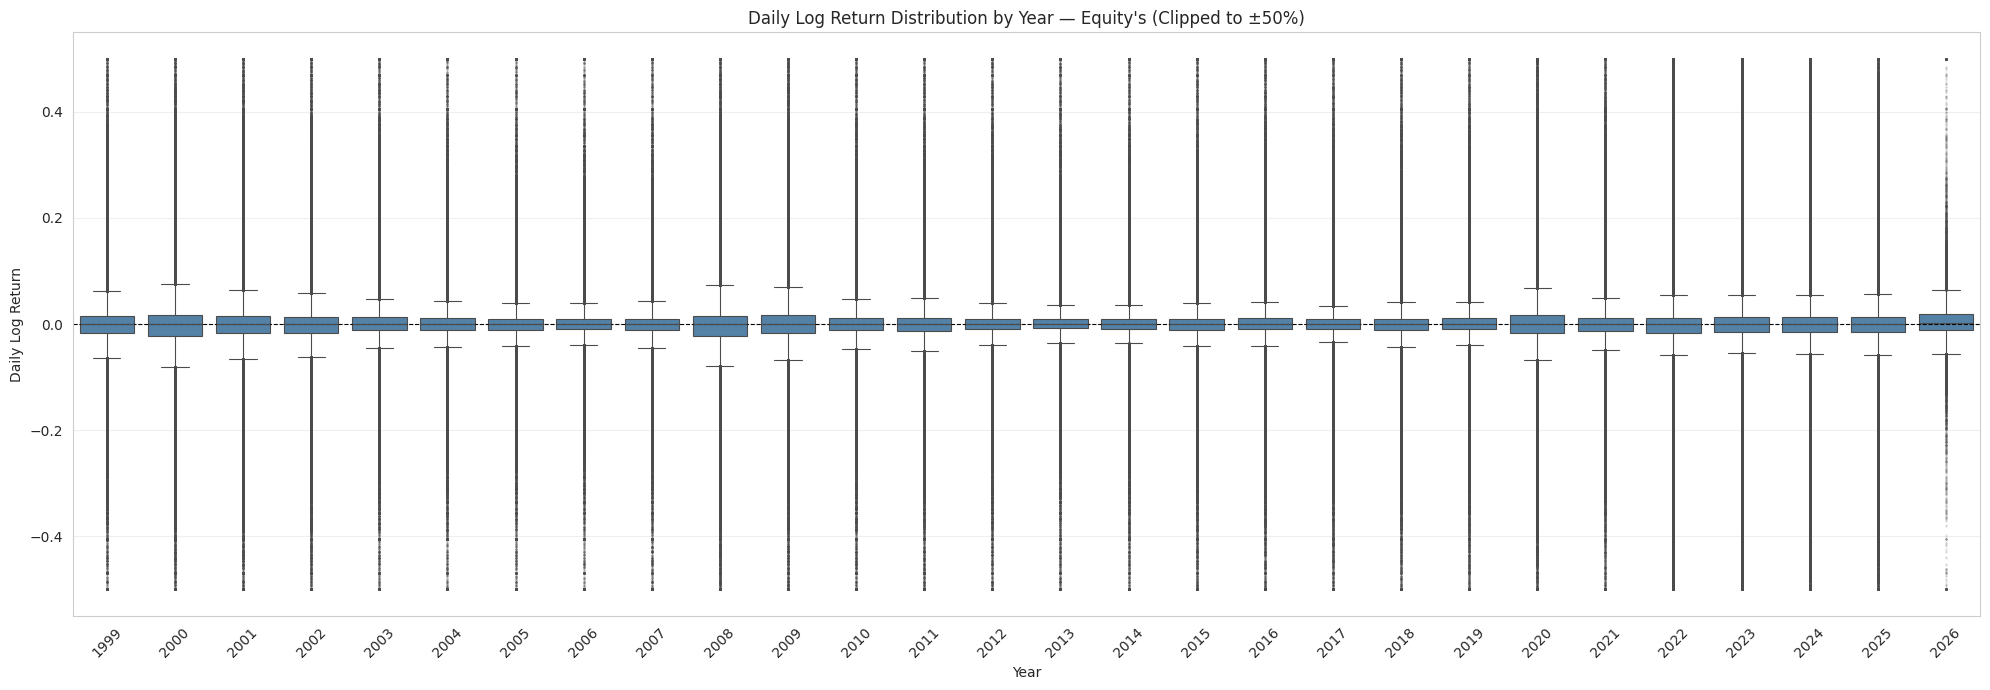


Years by Return Volatility (Std Dev of Daily Log Returns):
  2008: 0.068265
  2023: 0.066954
  2009: 0.065097
  2024: 0.062810
  2000: 0.062144
  2025: 0.061034
  2022: 0.060278
  2020: 0.059724
  2001: 0.059543
  2026: 0.058285
  2002: 0.056468
  2016: 0.054571
  2011: 0.054382
  2015: 0.054321
  2010: 0.054171
  1999: 0.051867
  2014: 0.051264
  2012: 0.049765
  2003: 0.049338
  2007: 0.048140
  2017: 0.048002
  2013: 0.047723
  2004: 0.044557
  2021: 0.044085
  2019: 0.043927
  2018: 0.043156
  2005: 0.042142
  2006: 0.040928


In [23]:
print("Log Return Distribution by Year")

# Attach year to the computed log returns for grouping
equity_returns_df['Year'] = equity_returns_df['Date'].dt.year

# Clip returns for plotting to prevent extreme penny stock values
# from collapsing the boxplot scale and obscuring the distribution shape
yearly_plot = equity_returns_df[['Year', 'log_return_1d']].copy()
yearly_plot['log_return_1d'] = yearly_plot['log_return_1d'].replace(
    [np.inf, -np.inf], np.nan
).clip(-0.5, 0.5)
yearly_plot = yearly_plot.dropna()

years_sorted = sorted(yearly_plot['Year'].unique())

plt.figure(figsize=(20, 7))
sns.boxplot(
    data=yearly_plot,
    x='Year',
    y='log_return_1d',
    order=years_sorted,
    color='steelblue',
    flierprops=dict(marker='.', markersize=1, alpha=0.2),
    linewidth=0.8
)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Daily Log Return Distribution by Year — Equity's (Clipped to ±50%)")
plt.xlabel("Year")
plt.ylabel("Daily Log Return")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print years with notably elevated volatility
yearly_std = yearly_plot.groupby('Year')['log_return_1d'].std().sort_values(ascending=False)
print("\nYears by Return Volatility (Std Dev of Daily Log Returns):")
for year, val in yearly_std.items():
    print(f"  {year}: {val:.6f}")

# **Section 8 — Market Regimes & Macro Correlation**

Normal:   01-05-2017 to 24-10-2017 (124 days), 50 tickers
Crisis:   03-01-2020 to 30-06-2020 (124 days), 50 tickers


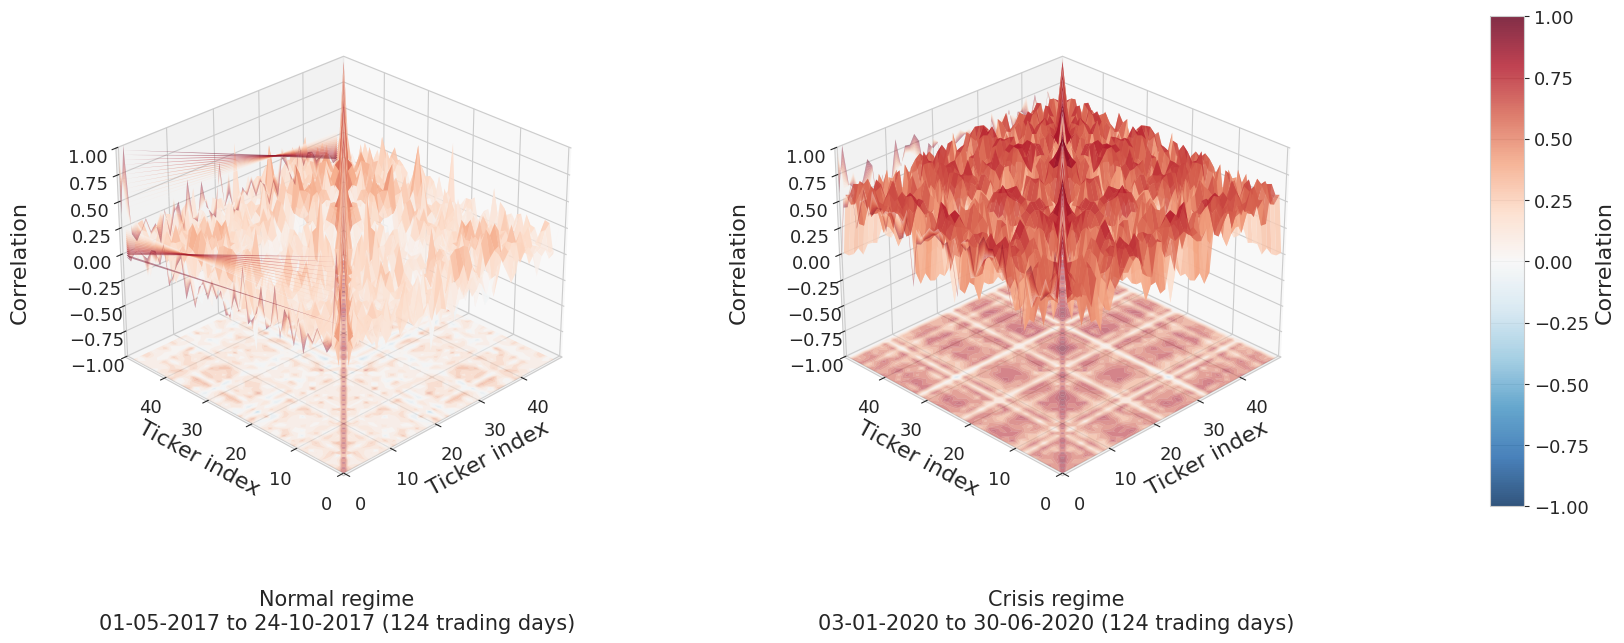

In [24]:
# Normal vs crisis correlation (3D surfaces + 2D contour projections; normal window matches crisis row count)

from matplotlib import colors as mcolors
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D

logger = logging.getLogger(__name__)

CRISIS_START, CRISIS_END = "2020-01-02", "2020-06-30"
N_TICKERS = 50
MIN_FRAC = 0.85

FONT_RC = {
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
}

eq = master_df[master_df["AssetClass"] == "equity"].copy()
eq["price"] = np.where(
    eq["Adjusted_close"].notna() & (eq["Adjusted_close"] > 0),
    eq["Adjusted_close"],
    eq["Close"],
)
top = (
    eq.groupby("Ticker", observed=True)["Date"]
    .count()
    .nlargest(N_TICKERS)
    .index.tolist()
)

def returns_panel_for_window(start: str, end: str, tickers: list) -> pd.DataFrame:
    sub = eq[(eq["Ticker"].isin(tickers)) & (eq["Date"] >= start) & (eq["Date"] <= end)]
    wide = sub.pivot(index="Date", columns="Ticker", values="price").sort_index()
    rets = np.log(wide / wide.shift(1))
    thresh = int(np.ceil(MIN_FRAC * len(rets)))
    good = [c for c in rets.columns if rets[c].notna().sum() >= thresh]
    rets = rets[good].dropna(how="all")
    return rets.dropna()

rets_c = returns_panel_for_window(CRISIS_START, CRISIS_END, top)
n_obs = len(rets_c)
tickers_use = rets_c.columns.tolist()
corr_c = rets_c.corr()
c0, c1 = rets_c.index.min(), rets_c.index.max()

sub_2017 = eq[(eq["Ticker"].isin(tickers_use)) & (eq["Date"] >= "2017-01-01") & (eq["Date"] <= "2017-12-31")]
wide_n = sub_2017.pivot(index="Date", columns="Ticker", values="price").sort_index()
wide_n = wide_n.reindex(columns=tickers_use)
rets_y = np.log(wide_n / wide_n.shift(1))
valid_n = rets_y.dropna()

normal_rets = None
if len(valid_n) >= n_obs:
    preferred = []
    fallback = None
    for i in range(len(valid_n) - n_obs + 1):
        chunk = valid_n.iloc[i : i + n_obs]
        if fallback is None:
            fallback = chunk
        d0 = chunk.index.min()
        if d0.month in (5, 6, 7, 8):
            preferred.append(chunk)
    normal_rets = preferred[0] if preferred else fallback
else:
    logger.warning(
        "Fewer than crisis-length complete rows in 2017 for this ticker set; "
        "relax MIN_FRAC or widen CRISIS_END or shrink N_TICKERS."
    )

def plot_corr_surface(
    ax,
    corr: pd.DataFrame,
    norm: mcolors.Normalize,
    cmap: str = "RdBu_r",
) -> plt.cm.ScalarMappable:
    """Plot correlation matrix as a 3D surface with 2D contour projections on three planes."""
    z = corr.values.astype(float)
    m = z.shape[0]
    x, y = np.meshgrid(np.arange(m, dtype=float), np.arange(m, dtype=float))
    levels = np.linspace(-1.0, 1.0, 29)
    pad = 0.5

    surf = ax.plot_surface(
        x,
        y,
        z,
        cmap=cmap,
        norm=norm,
        linewidth=0,
        antialiased=True,
        rstride=1,
        cstride=1,
        shade=True,
        alpha=0.82,
    )

    ax.contourf(
        x,
        y,
        z,
        zdir="z",
        offset=-1.0,
        cmap=cmap,
        norm=norm,
        levels=levels,
        alpha=0.55,
        antialiased=True,
    )
    ax.contourf(
        x,
        y,
        z,
        zdir="x",
        offset=-pad,
        cmap=cmap,
        norm=norm,
        levels=levels,
        alpha=0.45,
        antialiased=True,
    )
    ax.contourf(
        x,
        y,
        z,
        zdir="y",
        offset=(m - 1) + pad,
        cmap=cmap,
        norm=norm,
        levels=levels,
        alpha=0.45,
        antialiased=True,
    )

    ax.set_xlabel("Ticker index")
    ax.set_ylabel("Ticker index")
    ax.set_xlim(-pad, (m - 1) + pad)
    ax.set_ylim(-pad, (m - 1) + pad)
    ax.set_zlim(-1.0, 1.0)
    ax.view_init(elev=28, azim=-135)
    return surf

if normal_rets is not None and n_obs > 0:
    corr_n = normal_rets.corr()
    n0, n1 = normal_rets.index.min(), normal_rets.index.max()
    common = corr_n.columns.intersection(corr_c.columns)
    corr_n = corr_n.loc[common, common]
    corr_c = corr_c.loc[common, common]

    # Use strftime to format dates as DD-MM-YYYY
    n0_fmt, n1_fmt = n0.strftime('%d-%m-%Y'), n1.strftime('%d-%m-%Y')
    c0_fmt, c1_fmt = c0.strftime('%d-%m-%Y'), c1.strftime('%d-%m-%Y')

    print(f"Normal:   {n0_fmt} to {n1_fmt} ({len(normal_rets)} days), {len(common)} tickers")
    print(f"Crisis:   {c0_fmt} to {c1_fmt} ({len(rets_c)} days), {len(common)} tickers")

    norm = mcolors.Normalize(vmin=-1.0, vmax=1.0)

    with plt.rc_context(rc=FONT_RC):
        fig = plt.figure(figsize=(16, 7))
        gs = GridSpec(
            nrows=1,
            ncols=3,
            figure=fig,
            width_ratios=[1.0, 1.0, 0.06],
            wspace=0.38,
        )
        ax_l = fig.add_subplot(gs[0, 0], projection="3d")
        ax_r = fig.add_subplot(gs[0, 1], projection="3d")
        cax = fig.add_subplot(gs[0, 2])

        plot_corr_surface(ax_l, corr_n, norm)
        surf_c = plot_corr_surface(ax_r, corr_c, norm)

        for ax in (ax_l, ax_r):
            ax.tick_params(axis="z", labelsize=FONT_RC["xtick.labelsize"])

        cbar = fig.colorbar(surf_c, cax=cax)
        cbar.set_label("Correlation", fontsize=FONT_RC["axes.labelsize"])
        cbar.ax.tick_params(labelsize=FONT_RC["xtick.labelsize"])

        fig.subplots_adjust(left=0.06, right=0.98, bottom=0.24, top=0.94)
        fig.canvas.draw()

        pos_l = ax_l.get_position()
        pos_r = ax_r.get_position()

        for pos in (pos_l, pos_r):
            fig.text(
                max(0.01, pos.x0 - 0.045),
                pos.y0 + 0.5 * pos.height,
                "Correlation",
                rotation=90,
                ha="center",
                va="center",
                fontsize=FONT_RC["axes.labelsize"],
                transform=fig.transFigure,
            )

        # Updated captions using formatted date strings
        normal_caption = (
            f"Normal regime\n{n0_fmt} to {n1_fmt} ({len(normal_rets)} trading days)"
        )
        crisis_caption = (
            f"Crisis regime\n{c0_fmt} to {c1_fmt} ({len(rets_c)} trading days)"
        )

        cap_fs = FONT_RC["font.size"] + 1
        fig.text(
            pos_l.x0 + 0.5 * pos_l.width,
            0.09,
            normal_caption,
            ha="center",
            va="center",
            fontsize=cap_fs,
            transform=fig.transFigure,
        )
        fig.text(
            pos_r.x0 + 0.5 * pos_r.width,
            0.09,
            crisis_caption,
            ha="center",
            va="center",
            fontsize=cap_fs,
            transform=fig.transFigure,
        )

        plt.show()

MARKET REGIMES & MACRO CORRELATION
Using top liquid tickers: ['GAP', 'GOVX', 'AA', 'AAPL', 'AB']


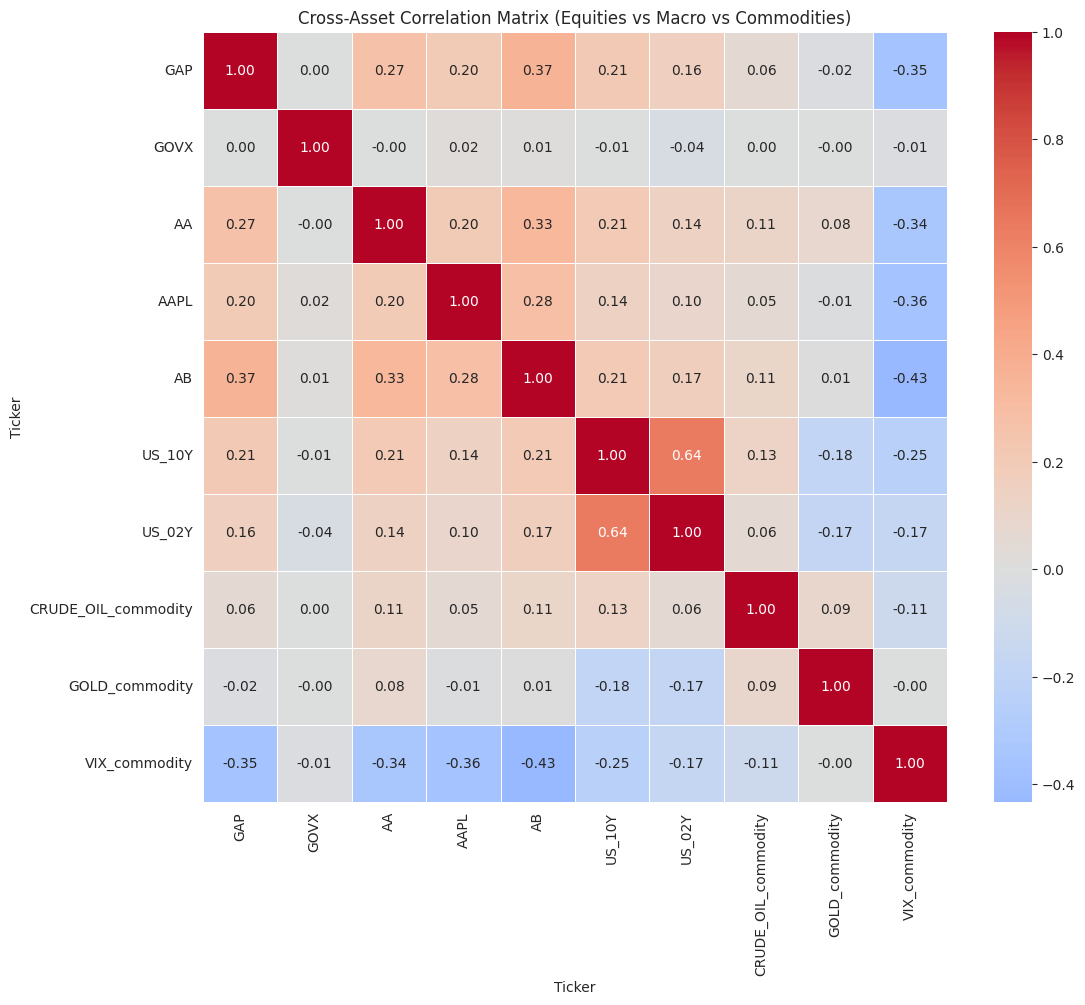

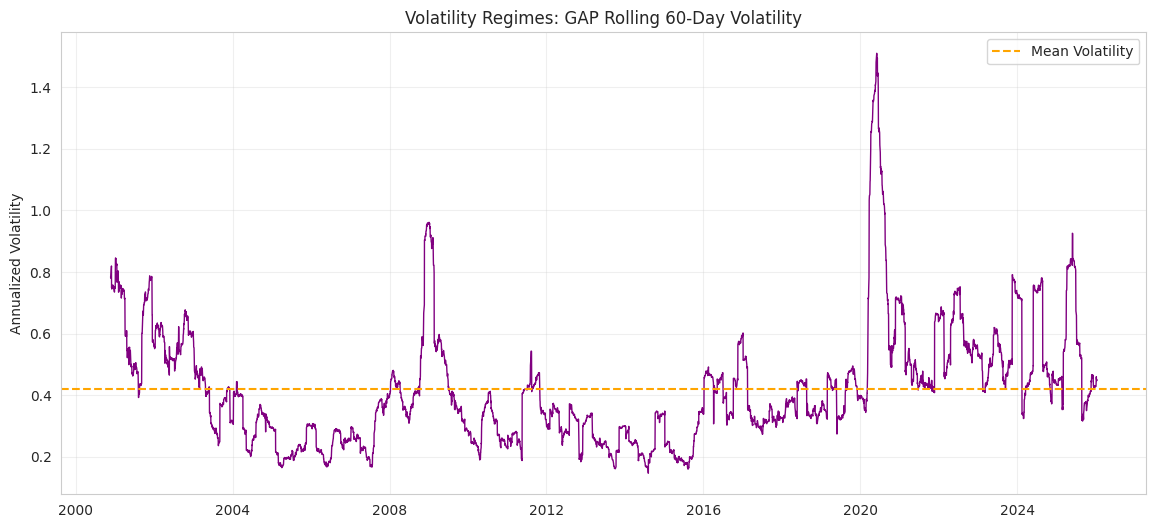


Stats for GAP Volatility:
  - Mean Volatility: 0.4192
  - Max Volatility (Crisis): 1.5107
  - Low Volatility (Boom): 0.1460


In [25]:
print("MARKET REGIMES & MACRO CORRELATION")

# We construct a global view using top liquid assets from the Master Dataset
# Identify Top Equities
top_equities = master_df[master_df['AssetClass']=='equity'].groupby("Ticker", observed=True)["Close"].count().nlargest(5).index.tolist()
print(f"Using top liquid tickers: {top_equities}")

# Pivot Master Data
# This pivots EVERYTHING (Equities, Macro, Commodities) into one wide dataframe
global_pivot = master_df.pivot(index='Date', columns='Ticker', values='Close')

# Select columns of interest: Top Equities + Key Macro + Commodities
cols_to_plot = top_equities + ['US_10Y', 'US_02Y', 'CRUDE_OIL_commodity', 'GOLD_commodity', 'VIX_commodity']
# Filter only columns that actually exist in the pivot
cols_to_plot = [c for c in cols_to_plot if c in global_pivot.columns]

subset_df = global_pivot[cols_to_plot].dropna()

# Calculate Correlation Matrix on Returns (or Changes for Yields)
# Note: For Yields (%), pct_change is volatile if close to 0, but standard practice for correlation
corr_matrix = subset_df.pct_change().corr()

# Plot Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Cross-Asset Correlation Matrix (Equities vs Macro vs Commodities)")
plt.show()

# Visualise Volatility Clustering (Regimes) for the main ticker
if top_equities:
    main_ticker = top_equities[0]
    returns = subset_df[main_ticker].pct_change().dropna()
    rolling_vol = returns.rolling(window=60).std() * np.sqrt(252)

    plt.figure(figsize=(14, 6))
    plt.plot(rolling_vol.index, rolling_vol.values, color='purple', linewidth=1)
    plt.title(f"Volatility Regimes: {main_ticker} Rolling 60-Day Volatility")
    plt.ylabel("Annualized Volatility")
    plt.axhline(rolling_vol.mean(), color='orange', linestyle='--', label='Mean Volatility')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"\nStats for {main_ticker} Volatility:")
    print(f"  - Mean Volatility: {rolling_vol.mean():.4f}")
    print(f"  - Max Volatility (Crisis): {rolling_vol.max():.4f}")
    print(f"  - Low Volatility (Boom): {rolling_vol.min():.4f}")

# **Section 9 — Correlation & Graph Structure**

CORRELATION & MARKET STRUCTURE ANALYSIS


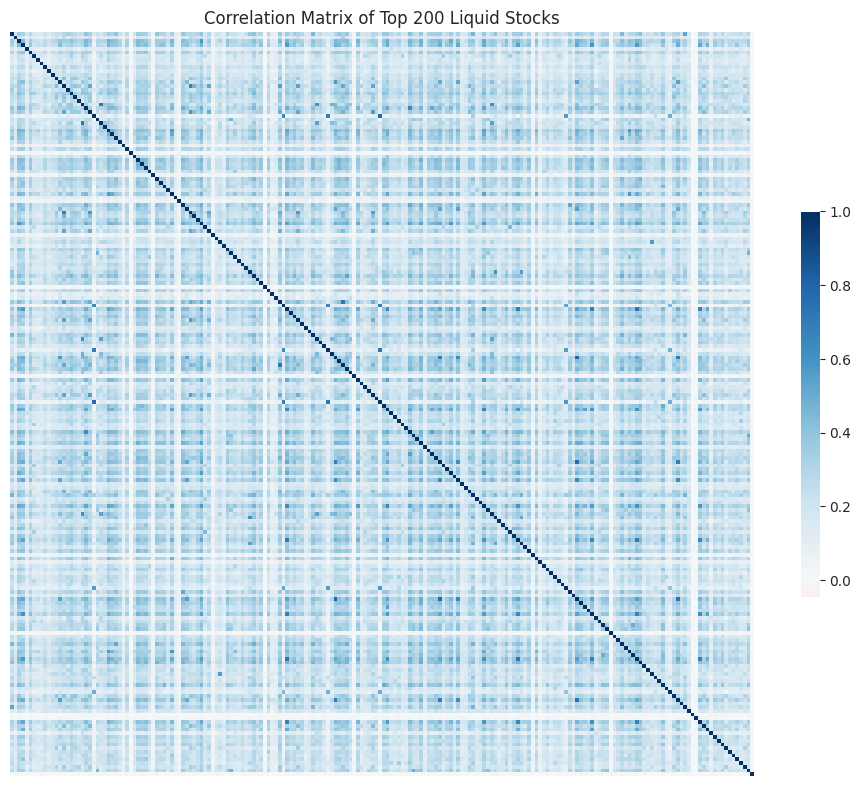

Average Pairwise Correlation: 0.2100
Median Pairwise Correlation: 0.2081


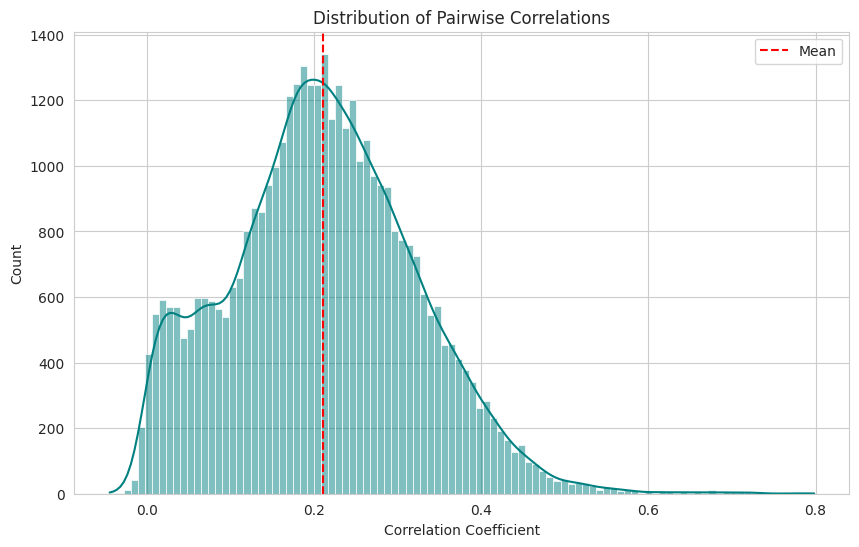

Correlation between Market Equities and US 10Y Yield: 0.1424


In [26]:
print("CORRELATION & MARKET STRUCTURE ANALYSIS")

# Select top 200 tickers by count from Master Dataset (Equities only)
top_tickers = master_df[master_df['AssetClass']=='equity'].groupby("Ticker", observed=True)["Close"].count().nlargest(200).index
subset_df = master_df[master_df['Ticker'].isin(top_tickers)].copy()

# Pivot to get matrix: Rows=Date, Cols=Ticker
price_matrix = subset_df.pivot(index="Date", columns="Ticker", values="Close")

# Calculate Log Returns
returns_matrix = np.log(price_matrix / price_matrix.shift(1))

# Compute Correlation Matrix
corr_matrix = returns_matrix.corr()

# Visualisation: Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="RdBu", center=0, square=True, cbar_kws={"shrink": 0.5})
plt.title("Correlation Matrix of Top 200 Liquid Stocks")
plt.axis("off")
plt.show()

# Distribution of Correlations
corr_values = corr_matrix.values.flatten()
corr_values = corr_values[corr_values != 1.0] # Remove diagonal
corr_values = corr_values[~np.isnan(corr_values)] # Remove NaNs

print(f"Average Pairwise Correlation: {np.mean(corr_values):.4f}")
print(f"Median Pairwise Correlation: {np.median(corr_values):.4f}")

plt.figure(figsize=(10, 6))
sns.histplot(corr_values, bins=100, kde=True, color="teal")
plt.title("Distribution of Pairwise Correlations")
plt.xlabel("Correlation Coefficient")
plt.axvline(np.mean(corr_values), color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()

# Macro Correlation Check
# Check correlation between Mean Market Return and 10Y Yield
market_return = returns_matrix.mean(axis=1)

# Get US_10Y from Master DF
us_10y = master_df[master_df["Ticker"] == "US_10Y"].set_index("Date")["Close"]
# Align timelines and compute percent change for yield
us_10y = us_10y.reindex(market_return.index).ffill().pct_change()

combined = pd.DataFrame({"Market": market_return, "US_10Y_Change": us_10y}).dropna()
macro_corr = combined.corr().iloc[0, 1]

print(f"Correlation between Market Equities and US 10Y Yield: {macro_corr:.4f}")

Thresholded Adjacency Matrix


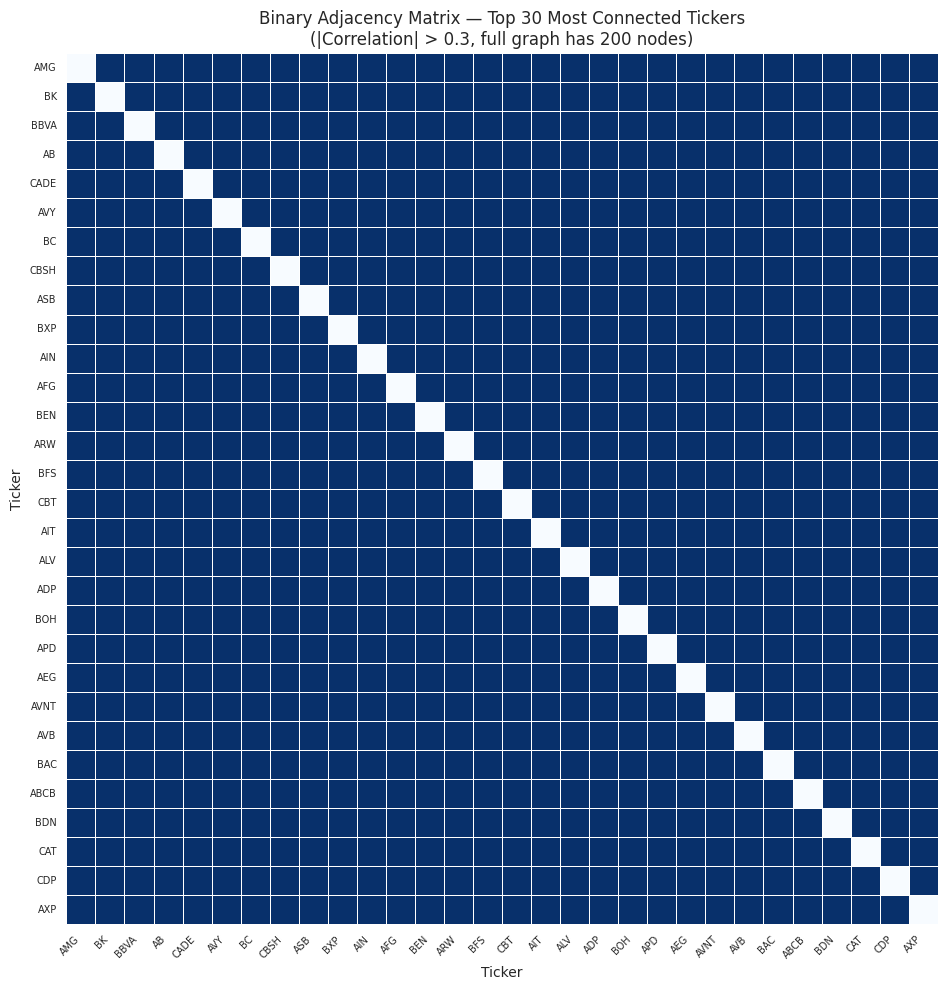


Graph Statistics at Threshold 0.3:
  Nodes (Tickers):       200
  Possible Edges:        39,800
  Retained Edges:        8,152
  Graph Density:         0.2048

Top 30 Subgraph:
  Most Connected Ticker: AMG (129 connections)
  Mean Degree (Top 30):  29.0 connections


In [34]:
print("Thresholded Adjacency Matrix")

# Apply an absolute correlation threshold to produce the binary adjacency
# matrix that the GNN layer receives - edges only exist where |correlation| > 0.3
# This threshold balances graph sparsity against information retention

threshold = 0.3
adjacency_bool = corr_matrix.abs() > threshold
adjacency_arr = adjacency_bool.to_numpy(dtype=np.int8, copy=True)
np.fill_diagonal(adjacency_arr, 0)
adjacency = pd.DataFrame(
    adjacency_arr,
    index=corr_matrix.index,
    columns=corr_matrix.columns,
)

# Compute degree for all tickers to identify the most connected nodes
degree_all = adjacency.sum(axis=1).sort_values(ascending=False)

# Select the top 30 most connected tickers for a readable visualisation
# These are the nodes most likely to reveal genuine cluster structure
top_30 = degree_all.head(30).index
adjacency_30 = adjacency.loc[top_30, top_30]

plt.figure(figsize=(12, 10))
sns.heatmap(
    adjacency_30,
    cmap="Blues",
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar=False,
    xticklabels=True,
    yticklabels=True,
)
plt.title(
    f"Binary Adjacency Matrix — Top 30 Most Connected Tickers\n"
    f"(|Correlation| > {threshold}, full graph has {adjacency.shape[0]} nodes)"
)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

# Full graph statistics computed from the complete 200-ticker adjacency
total_possible_edges = adjacency.shape[0] * (adjacency.shape[0] - 1)
actual_edges = int(adjacency.to_numpy().sum())
density = actual_edges / total_possible_edges

print(f"\nGraph Statistics at Threshold {threshold}:")
print(f"  Nodes (Tickers):       {adjacency.shape[0]:,}")
print(f"  Possible Edges:        {total_possible_edges:,}")
print(f"  Retained Edges:        {actual_edges:,}")
print(f"  Graph Density:         {density:.4f}")
print(f"\nTop 30 Subgraph:")
print(f"  Most Connected Ticker: {degree_all.index[0]} ({degree_all.iloc[0]} connections)")
print(f"  Mean Degree (Top 30):  {adjacency_30.sum(axis=1).mean():.1f} connections")

Degree Distribution


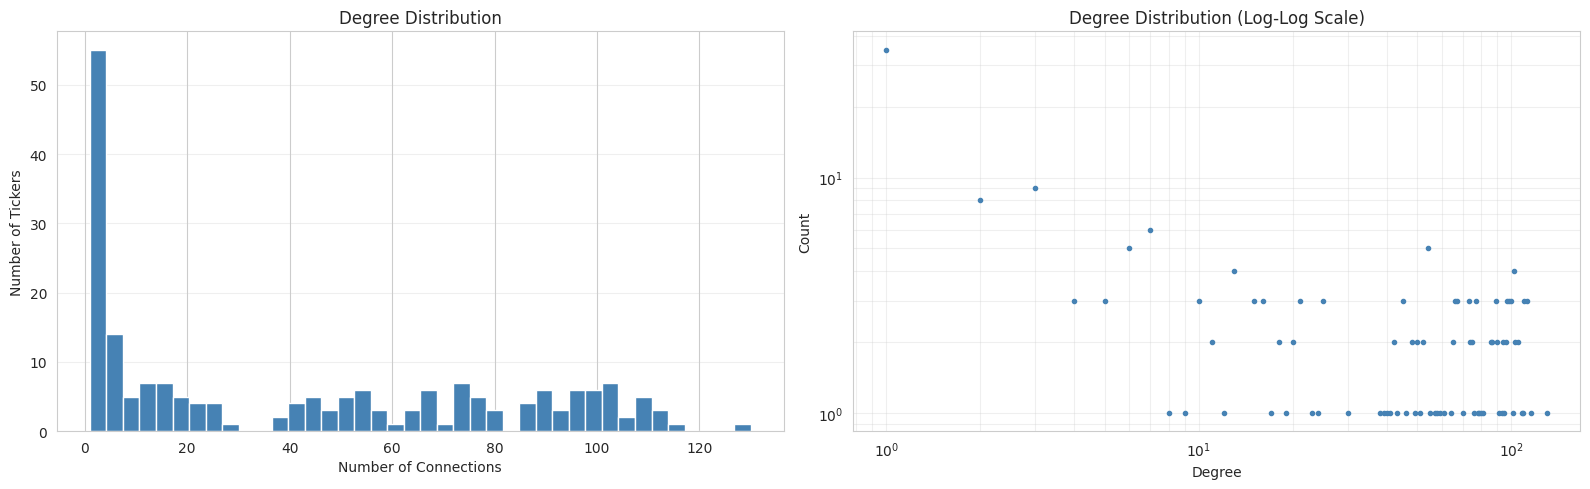


Degree Summary:
  Mean Degree:    41.8 connections
  Median Degree:  25.0 connections
  Max Degree:     130 (most connected ticker: AMG)
  Min Degree:     1 (least connected ticker: ABEV)
  Isolated Nodes: 0 tickers with no connections at this threshold


In [32]:
print("Degree Distribution")

# Degree = number of connections each ticker has in the thresholded graph
# A scale-free distribution (power law shape) supports the graph construction approach
# A uniform distribution would suggest the threshold needs revisiting

degree_series = adjacency.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of degrees
axes[0].hist(degree_series.values, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title("Degree Distribution")
axes[0].set_xlabel("Number of Connections")
axes[0].set_ylabel("Number of Tickers")
axes[0].grid(axis='y', alpha=0.3)

# Log-log plot to check for power law behaviour
degree_counts = degree_series.value_counts().sort_index()
axes[1].loglog(degree_counts.index, degree_counts.values,
               marker='.', linestyle='none', color='steelblue', markersize=6)
axes[1].set_title("Degree Distribution (Log-Log Scale)")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f"\nDegree Summary:")
print(f"  Mean Degree:    {degree_series.mean():.1f} connections")
print(f"  Median Degree:  {degree_series.median():.1f} connections")
print(f"  Max Degree:     {degree_series.max():,} (most connected ticker: {degree_series.idxmax()})")
print(f"  Min Degree:     {degree_series.min():,} (least connected ticker: {degree_series.idxmin()})")
print(f"  Isolated Nodes: {(degree_series == 0).sum()} tickers with no connections at this threshold")

Edge Weight Distribution


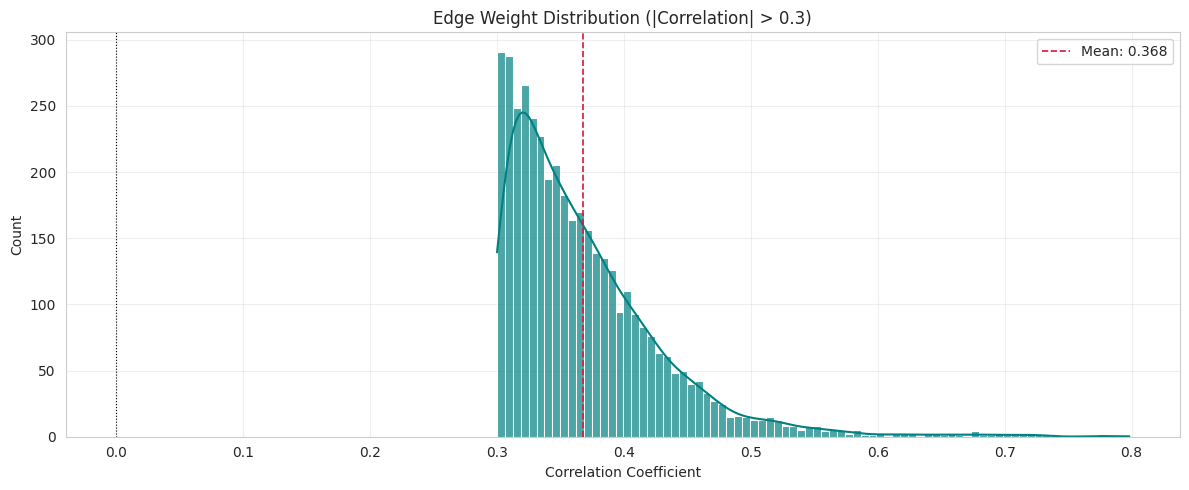


Edge Weight Summary:
  Retained Edges:       4,076
  Mean Weight:          0.3678
  Median Weight:        0.3524
  Positive Edges:       4,076 (100.0%)
  Negative Edges:       0 (0.0%)


In [35]:
print("Edge Weight Distribution")

# Distribution of retained correlation values above the threshold
# Shows the typical edge weight magnitude the GNN layer works with

# Extract upper triangle only to avoid counting each pair twice
upper_tri_mask = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
all_corr_values = corr_matrix.values[upper_tri_mask]

# Retain only values above the threshold in absolute terms
retained_weights = all_corr_values[np.abs(all_corr_values) > threshold]
retained_weights = retained_weights[np.isfinite(retained_weights)]

plt.figure(figsize=(12, 5))
sns.histplot(retained_weights, bins=80, kde=True, color='teal', alpha=0.7)
plt.axvline(retained_weights.mean(), color='crimson', linestyle='--',
            linewidth=1.2, label=f'Mean: {retained_weights.mean():.3f}')
plt.axvline(0, color='black', linewidth=0.8, linestyle=':')
plt.title(f"Edge Weight Distribution (|Correlation| > {threshold})")
plt.xlabel("Correlation Coefficient")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nEdge Weight Summary:")
print(f"  Retained Edges:       {len(retained_weights):,}")
print(f"  Mean Weight:          {retained_weights.mean():.4f}")
print(f"  Median Weight:        {np.median(retained_weights):.4f}")
print(f"  Positive Edges:       {(retained_weights > 0).sum():,} ({(retained_weights > 0).mean():.1%})")
print(f"  Negative Edges:       {(retained_weights < 0).sum():,} ({(retained_weights < 0).mean():.1%})")

Commodity Hub Node Connectivity


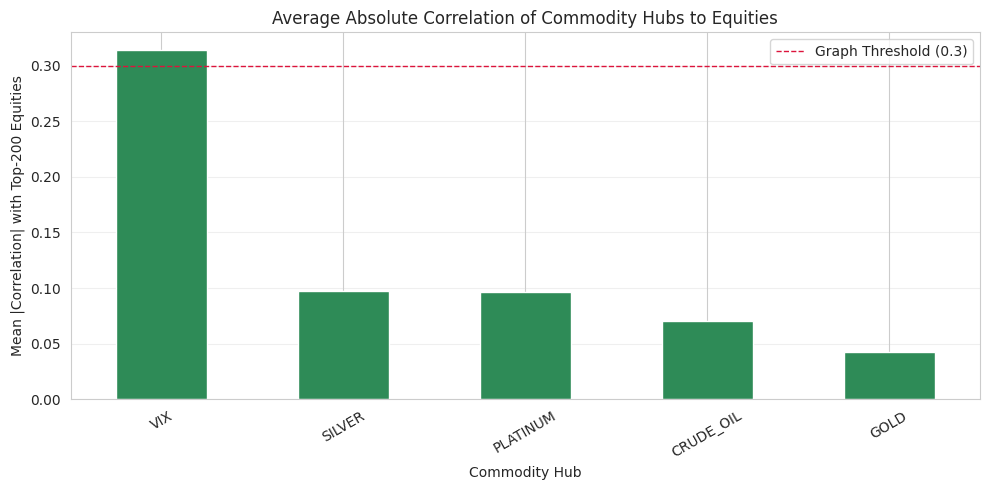


Hub Node Connectivity:
  VIX            : 0.3142 mean |correlation| (above graph threshold)
  SILVER         : 0.0974 mean |correlation| (below graph threshold)
  PLATINUM       : 0.0967 mean |correlation| (below graph threshold)
  CRUDE_OIL      : 0.0700 mean |correlation| (below graph threshold)
  GOLD           : 0.0428 mean |correlation| (below graph threshold)


In [52]:
import warnings
warnings.filterwarnings("ignore", message=".*Sorting by default when concatenating.*")

print("Commodity Hub Node Connectivity")

# For each commodity hub node, compute its average absolute correlation
# to all equity tickers in the top-200 pool
# This validates the decision to treat commodities as hub nodes in the graph layer

# Commodity tickers as they appear in the master dataset
hub_candidates = ['CRUDE_OIL_commodity', 'GOLD_commodity', 'VIX_commodity',
                  'SILVER_commodity', 'PLATINUM_commodity']

# Build a returns series for each hub from the global pivot
hub_results = {}

for hub in hub_candidates:
    if hub not in global_pivot.columns:
        continue

    hub_returns = global_pivot[hub].pct_change().dropna()

    # Correlate against each equity in the returns matrix
    correlations = []
    for ticker in returns_matrix.columns:
        equity_ret = returns_matrix[ticker].dropna()
        aligned    = pd.concat([hub_returns, equity_ret], axis=1).dropna()
        if len(aligned) < 60:
            continue
        corr_val = aligned.iloc[:, 0].corr(aligned.iloc[:, 1])
        if np.isfinite(corr_val):
            correlations.append(abs(corr_val))

    if correlations:
        hub_results[hub.replace('_commodity', '')] = np.mean(correlations)

hub_df = pd.Series(hub_results).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
hub_df.plot(kind='bar', color='seagreen', edgecolor='white')
plt.title("Average Absolute Correlation of Commodity Hubs to Equities")
plt.ylabel("Mean |Correlation| with Top-200 Equities")
plt.xlabel("Commodity Hub")
plt.xticks(rotation=30)
plt.axhline(threshold, color='crimson', linestyle='--',
            linewidth=1, label=f'Graph Threshold ({threshold})')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nHub Node Connectivity:")
for hub, val in hub_df.items():
    above = "above graph threshold" if val > threshold else "below graph threshold"
    print(f"  {hub:<15}: {val:.4f} mean |correlation| ({above})")

# **Section 10 — Target Variable Analysis**

Target Variable: log_return_1d Cross-Sectional Distribution


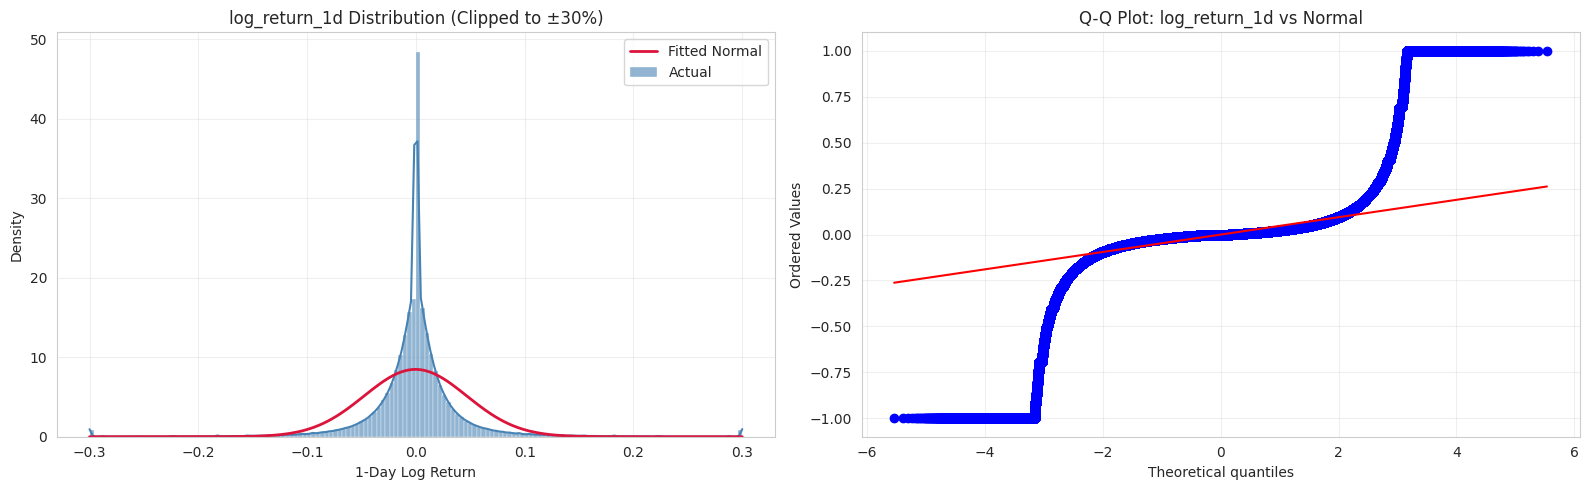


log_return_1d Summary:
  Observations: 43,930,380
  Mean:         -0.000423
  Std Dev:      0.189976
  Kurtosis:     2042.5358
  Skewness:     0.1676


In [53]:
print("Target Variable: log_return_1d Cross-Sectional Distribution")

from scipy.stats import norm as gaussian

# log_return_1d is the supervised target for the model
# We examine its cross-sectional properties across all equity tickers
# to confirm it is a well-behaved prediction target

# Reuse the computed column from Section 7
target_1d = equity_returns_df["log_return_1d"].replace([np.inf, -np.inf], np.nan).dropna()

# Clip for plotting
target_1d_plot = target_1d.clip(-0.3, 0.3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution vs normal
sns.histplot(
    target_1d_plot,
    bins=150,
    kde=True,
    stat="density",
    color="steelblue",
    alpha=0.6,
    ax=axes[0],
    label="Actual",
)
mu_1d, std_1d = gaussian.fit(target_1d_plot)
x_1d = np.linspace(-0.3, 0.3, 300)
axes[0].plot(
    x_1d,
    gaussian.pdf(x_1d, mu_1d, std_1d),
    color="crimson",
    linewidth=2,
    label="Fitted Normal",
)
axes[0].set_title("log_return_1d Distribution (Clipped to ±30%)")
axes[0].set_xlabel("1-Day Log Return")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(target_1d.clip(-1, 1), dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: log_return_1d vs Normal")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nlog_return_1d Summary:")
print(f"  Observations: {len(target_1d):,}")
print(f"  Mean:         {target_1d.mean():.6f}")
print(f"  Std Dev:      {target_1d.std():.6f}")
print(f"  Kurtosis:     {kurtosis(target_1d):.4f}")
print(f"  Skewness:     {skew(target_1d):.4f}")

Target Variable: log_return_5d Distribution for Comparison


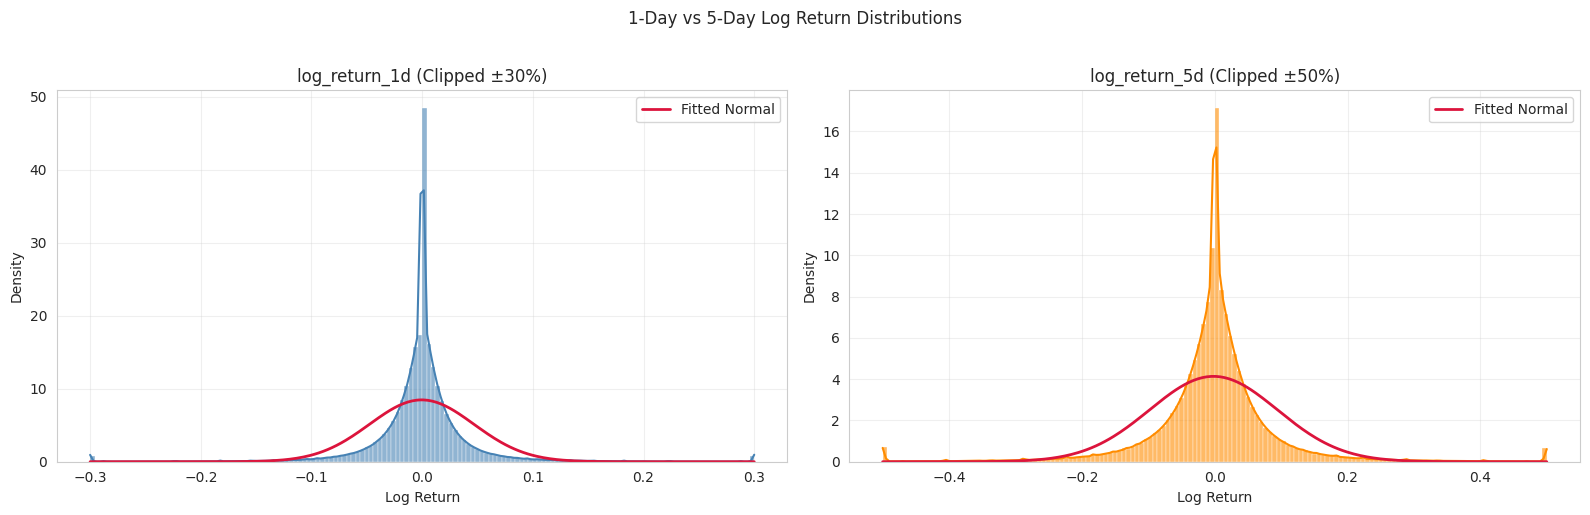


log_return_5d Summary:
  Observations: 43,844,785
  Mean:         -0.002110
  Std Dev:      0.226255
  Kurtosis:     1155.5834
  Skewness:     0.3951

  Std Dev Ratio (5d / 1d): 1.1910
  Expected if Independent: 2.2361 (overlapping windows will be lower)


In [54]:
print("Target Variable: log_return_5d Distribution for Comparison")

# Compute log_return_5d inline as a 5-day rolling sum of log_return_1d
# This matches the pipeline definition in stage3_engineer_features.py
equity_returns_df = equity_returns_df.sort_values(['Ticker', 'Date'])
equity_returns_df['log_return_5d'] = (
    equity_returns_df.groupby('Ticker', observed=True)['log_return_1d']
    .transform(lambda x: x.rolling(window=5, min_periods=5).sum())
)

target_5d = equity_returns_df['log_return_5d'].replace(
    [np.inf, -np.inf], np.nan
).dropna()

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, data, label, colour in zip(
    axes,
    [target_1d.clip(-0.3, 0.3), target_5d.clip(-0.5, 0.5)],
    ['log_return_1d (Clipped ±30%)', 'log_return_5d (Clipped ±50%)'],
    ['steelblue', 'darkorange']
):
    sns.histplot(data, bins=150, kde=True, stat='density',
                 color=colour, alpha=0.6, ax=ax)
    mu_v, std_v = stats.norm.fit(data)
    x_v = np.linspace(data.min(), data.max(), 300)
    ax.plot(x_v, stats.norm.pdf(x_v, mu_v, std_v), color='crimson', linewidth=2, label='Fitted Normal')
    ax.set_title(label)
    ax.set_xlabel("Log Return")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("1-Day vs 5-Day Log Return Distributions", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nlog_return_5d Summary:")
print(f"  Observations: {len(target_5d):,}")
print(f"  Mean:         {target_5d.mean():.6f}")
print(f"  Std Dev:      {target_5d.std():.6f}")
print(f"  Kurtosis:     {kurtosis(target_5d):.4f}")
print(f"  Skewness:     {skew(target_5d):.4f}")
print(f"\n  Std Dev Ratio (5d / 1d): {target_5d.std() / target_1d.std():.4f}")
print(f"  Expected if Independent: {np.sqrt(5):.4f} (overlapping windows will be lower)")

5-Day Return Autocorrelation


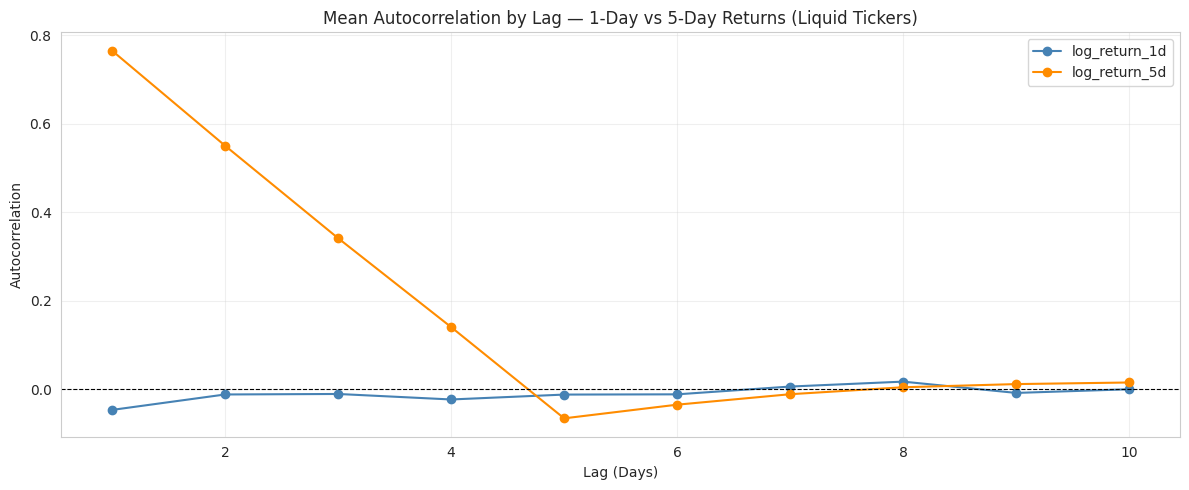


Mean Autocorrelations (averaged across 26 liquid tickers):
  Lag       1d Return    5d Return
  1           -0.0472       0.7654
  2           -0.0122       0.5504
  3           -0.0111       0.3413
  4           -0.0235       0.1402
  5           -0.0125      -0.0662
  6           -0.0119      -0.0353
  7            0.0057      -0.0117
  8            0.0168       0.0041
  9           -0.0087       0.0112
  10          -0.0004       0.0149


In [55]:
print("5-Day Return Autocorrelation")

# Overlapping 5-day windows create artificial autocorrelation in log_return_5d
# This inflates the Sharpe ratio when used as a daily prediction target
# because the PnL series inherits the smoothed autocorrelation structure

# Sample liquid tickers to keep computation tractable
liquid_sample_tickers = illiquidity_ratio[illiquidity_ratio < 0.05].index[:30].tolist()
liquid_sample_tickers = [t for t in liquid_sample_tickers
                         if t in equity_returns_df['Ticker'].cat.categories]

autocorr_1d_results = []
autocorr_5d_results = []
lags = range(1, 11)

for ticker in liquid_sample_tickers:
    ticker_data = equity_returns_df[equity_returns_df['Ticker'] == ticker]

    ret_1d = ticker_data['log_return_1d'].dropna()
    ret_5d = ticker_data['log_return_5d'].dropna()

    if len(ret_1d) < 100 or len(ret_5d) < 100:
        continue

    autocorr_1d_results.append([ret_1d.autocorr(lag=l) for l in lags])
    autocorr_5d_results.append([ret_5d.autocorr(lag=l) for l in lags])

mean_ac_1d = np.nanmean(autocorr_1d_results, axis=0)
mean_ac_5d = np.nanmean(autocorr_5d_results, axis=0)

plt.figure(figsize=(12, 5))
plt.plot(list(lags), mean_ac_1d, marker='o', color='steelblue',
         linewidth=1.5, label='log_return_1d')
plt.plot(list(lags), mean_ac_5d, marker='o', color='darkorange',
         linewidth=1.5, label='log_return_5d')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Mean Autocorrelation by Lag — 1-Day vs 5-Day Returns (Liquid Tickers)")
plt.xlabel("Lag (Days)")
plt.ylabel("Autocorrelation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMean Autocorrelations (averaged across {len(autocorr_5d_results)} liquid tickers):")
print(f"  {'Lag':<6} {'1d Return':>12} {'5d Return':>12}")
for lag, ac1, ac5 in zip(lags, mean_ac_1d, mean_ac_5d):
    print(f"  {lag:<6} {ac1:>12.4f} {ac5:>12.4f}")

Target Temporal Alignment Check


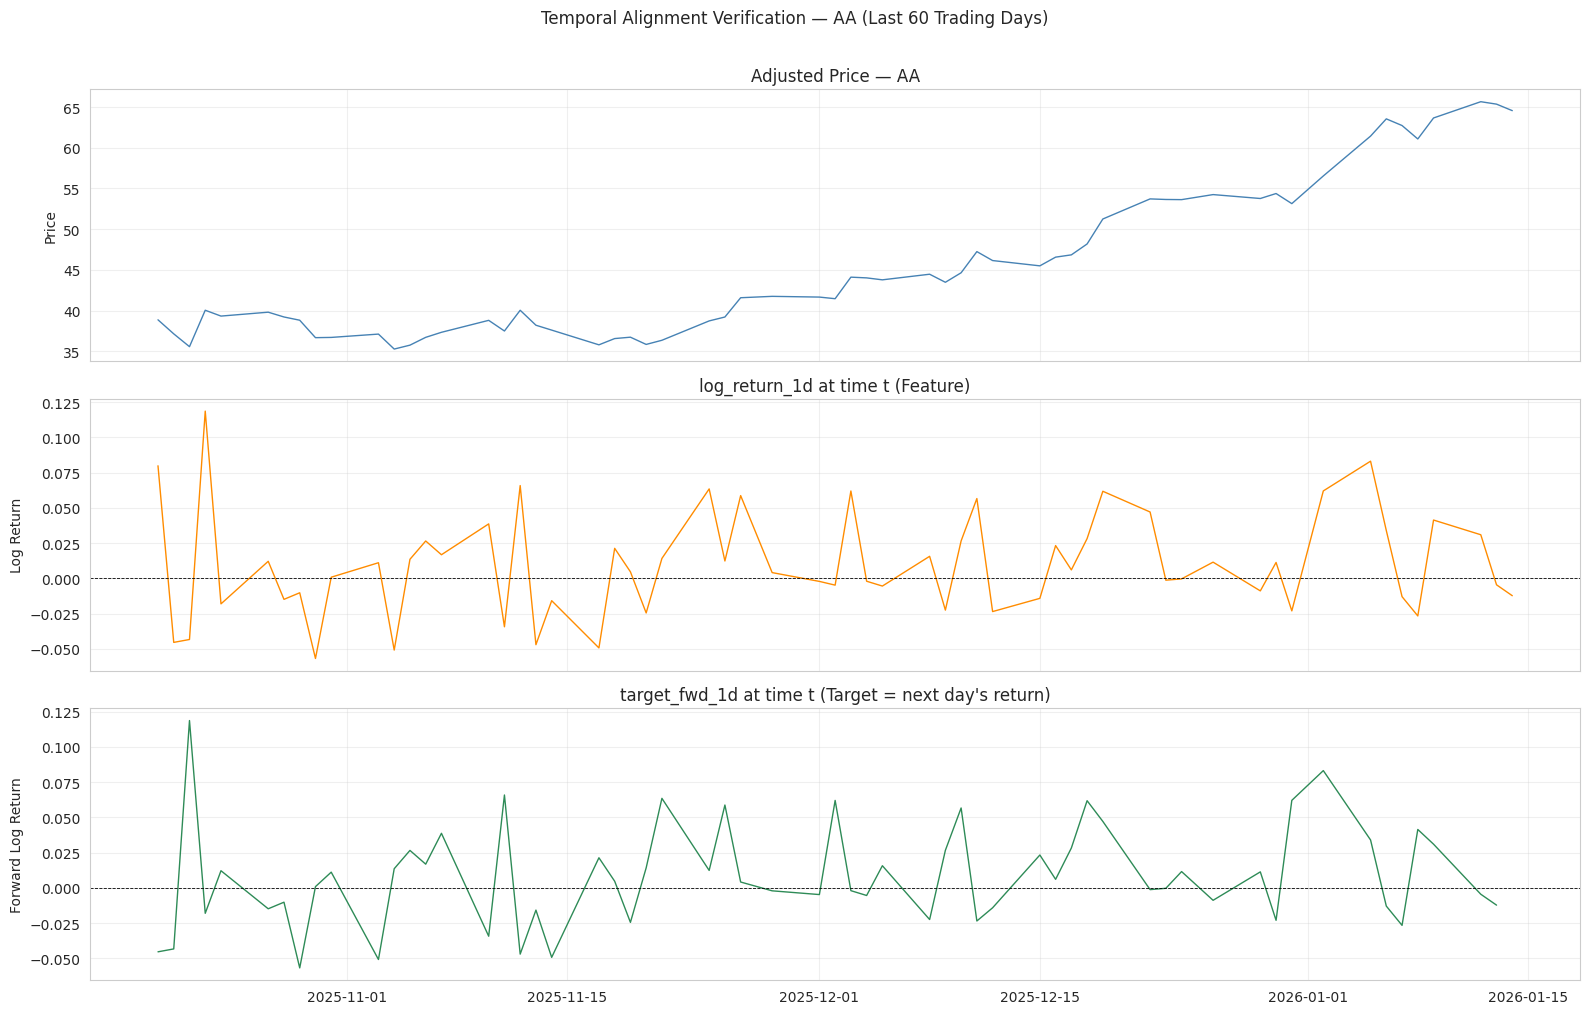


Alignment Check for AA:
  Contemporaneous correlation (t vs t):   -0.1009 (near zero = clean)
  Lag-1 correlation (t vs t-1):           1.0000


In [56]:
print("Target Temporal Alignment Check")

# Verify that the forward target is shifted exactly one day ahead
# with no look-ahead bias visible in the price or return series
# A clean construction shows the target at t corresponding to the
# return realised between t and t+1, not t-1 to t

# Select one liquid ticker for illustration
check_ticker = liquid_sample_tickers[0] if liquid_sample_tickers else None

if check_ticker:
    ticker_check = equity_returns_df[
        equity_returns_df['Ticker'] == check_ticker
    ].sort_values('Date').tail(60).copy()

    # Forward target: return that will be realised on the next day
    ticker_check['target_fwd_1d'] = ticker_check['log_return_1d'].shift(-1)

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(ticker_check['Date'], ticker_check['price'],
                 color='steelblue', linewidth=1)
    axes[0].set_title(f"Adjusted Price — {check_ticker}")
    axes[0].set_ylabel("Price")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(ticker_check['Date'], ticker_check['log_return_1d'],
                 color='darkorange', linewidth=1)
    axes[1].axhline(0, color='black', linewidth=0.6, linestyle='--')
    axes[1].set_title("log_return_1d at time t (Feature)")
    axes[1].set_ylabel("Log Return")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(ticker_check['Date'], ticker_check['target_fwd_1d'],
                 color='seagreen', linewidth=1)
    axes[2].axhline(0, color='black', linewidth=0.6, linestyle='--')
    axes[2].set_title("target_fwd_1d at time t (Target = next day's return)")
    axes[2].set_ylabel("Forward Log Return")
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f"Temporal Alignment Verification — {check_ticker} (Last 60 Trading Days)",
                 y=1.01)
    plt.tight_layout()
    plt.show()

    # Numerical check: contemporaneous correlation between feature and target
    # Should be near zero if the shift is clean
    contemp_corr = ticker_check['log_return_1d'].corr(ticker_check['target_fwd_1d'])
    lag1_corr    = ticker_check['log_return_1d'].corr(
        ticker_check['target_fwd_1d'].shift(1)
    )

    print(f"\nAlignment Check for {check_ticker}:")
    print(f"  Contemporaneous correlation (t vs t):   {contemp_corr:.4f} (near zero = clean)")
    print(f"  Lag-1 correlation (t vs t-1):           {lag1_corr:.4f}")
else:
    print("No liquid tickers available for alignment check.")

# **Section 11 — Data Leakage Audit**

In [57]:
print("Computing Engineered Features for Leakage Audit")

# We replicate the pipeline's feature engineering inline using a sample of
# liquid equity tickers so the leakage audit operates on the same feature
# set that the model will actually receive, not just raw prices

# Use the liquid tickers identified earlier to keep this tractable
audit_tickers = illiquidity_ratio[illiquidity_ratio < 0.05].index[:50].tolist()

audit_df = master_df[
    (master_df['AssetClass'] == 'equity') &
    (master_df['Ticker'].isin(audit_tickers))
].copy()

audit_df['price'] = np.where(
    audit_df['Adjusted_close'].notna() & (audit_df['Adjusted_close'] > 0),
    audit_df['Adjusted_close'],
    audit_df['Close']
)

audit_df = audit_df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# Log returns at 1, 5 and 20 day horizons (Campbell et al., 1997)
for h in [1, 5, 20]:
    prices    = audit_df['price'].replace(0, np.nan)
    shifted   = audit_df.groupby('Ticker', observed=True)['price'].shift(h).replace(0, np.nan)
    audit_df[f'log_return_{h}d'] = np.log(prices / shifted)

# Realised volatility at 10, 22 and 60 day windows (Andersen et al., 2003)
for w in [10, 22, 60]:
    rolling_std = (
        audit_df.groupby('Ticker', observed=True)['log_return_1d']
        .transform(lambda x: x.rolling(window=w).std())
    )
    audit_df[f'vol_{w}d'] = rolling_std

# Skip-month momentum at 3, 6 and 12 month horizons (Jegadeesh & Titman, 1993)
momentum_params = {'mom_3m': (63, 21), 'mom_6m': (126, 21), 'mom_12m': (252, 21)}
for col, (formation, skip) in momentum_params.items():
    p_skip      = audit_df.groupby('Ticker', observed=True)['price'].shift(skip)
    p_formation = audit_df.groupby('Ticker', observed=True)['price'].shift(formation)
    audit_df[col] = (p_skip / p_formation) - 1

# Higher moments at 60 day window
for stat_name, func in [('skew_60d', 'skew'), ('kurt_60d', 'kurt')]:
    audit_df[stat_name] = (
        audit_df.groupby('Ticker', observed=True)['log_return_1d']
        .transform(lambda x: getattr(x.rolling(window=60), func)())
    )
audit_df['tail_risk'] = audit_df['skew_60d'] * audit_df['kurt_60d']

# Forward target — what the model is predicting
audit_df['target_fwd_1d'] = (
    audit_df.groupby('Ticker', observed=True)['log_return_1d']
    .transform(lambda x: x.shift(-1))
)

# Feature columns available to the model at time t
feature_cols = [
    'log_return_1d', 'log_return_5d', 'log_return_20d',
    'vol_10d', 'vol_22d', 'vol_60d',
    'mom_3m', 'mom_6m', 'mom_12m',
    'skew_60d', 'kurt_60d', 'tail_risk'
]

print(f"\nAudit dataset shape: {audit_df.shape}")
print(f"Tickers included:    {audit_df['Ticker'].nunique()}")
print(f"Feature columns:     {feature_cols}")

Computing Engineered Features for Leakage Audit

Audit dataset shape: (123426, 30)
Tickers included:    50
Feature columns:     ['log_return_1d', 'log_return_5d', 'log_return_20d', 'vol_10d', 'vol_22d', 'vol_60d', 'mom_3m', 'mom_6m', 'mom_12m', 'skew_60d', 'kurt_60d', 'tail_risk']


Feature-to-Target Contemporaneous Correlation


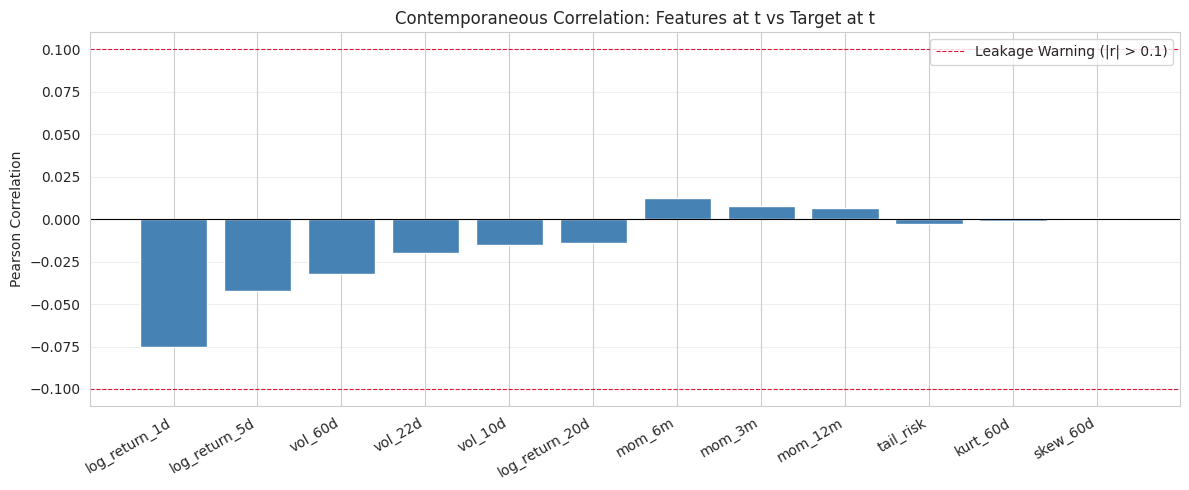


Contemporaneous Correlations (Features at t vs Target at t):
  log_return_1d       :  -0.0755
  log_return_5d       :  -0.0421
  vol_60d             :  -0.0321
  vol_22d             :  -0.0198
  vol_10d             :  -0.0154
  log_return_20d      :  -0.0143
  mom_6m              :   0.0127
  mom_3m              :   0.0075
  mom_12m             :   0.0066
  tail_risk           :  -0.0028
  kurt_60d            :  -0.0013
  skew_60d            :   0.0010


In [58]:
print("Feature-to-Target Contemporaneous Correlation")

# For each engineered feature at time t, compute Pearson correlation with
# the forward target at time t (which should represent t+1's return)
# A clean pipeline shows near-zero contemporaneous correlation
# High values indicate the feature contains information from the future

audit_clean = audit_df[feature_cols + ['target_fwd_1d']].replace(
    [np.inf, -np.inf], np.nan
).dropna()

contemp_corrs = {}
for col in feature_cols:
    corr_val = audit_clean[col].corr(audit_clean['target_fwd_1d'])
    contemp_corrs[col] = corr_val

contemp_series = pd.Series(contemp_corrs).sort_values(key=abs, ascending=False)

plt.figure(figsize=(12, 5))
colours = ['crimson' if abs(v) > 0.1 else 'steelblue' for v in contemp_series.values]
plt.bar(contemp_series.index, contemp_series.values, color=colours, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(0.1, color='crimson', linewidth=0.8, linestyle='--', label='Leakage Warning (|r| > 0.1)')
plt.axhline(-0.1, color='crimson', linewidth=0.8, linestyle='--')
plt.title("Contemporaneous Correlation: Features at t vs Target at t")
plt.ylabel("Pearson Correlation")
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nContemporaneous Correlations (Features at t vs Target at t):")
for feat, val in contemp_series.items():
    flag = " — leakage warning" if abs(val) > 0.1 else ""
    print(f"  {feat:<20}: {val:>8.4f}{flag}")

Lagged Correlation Matrix


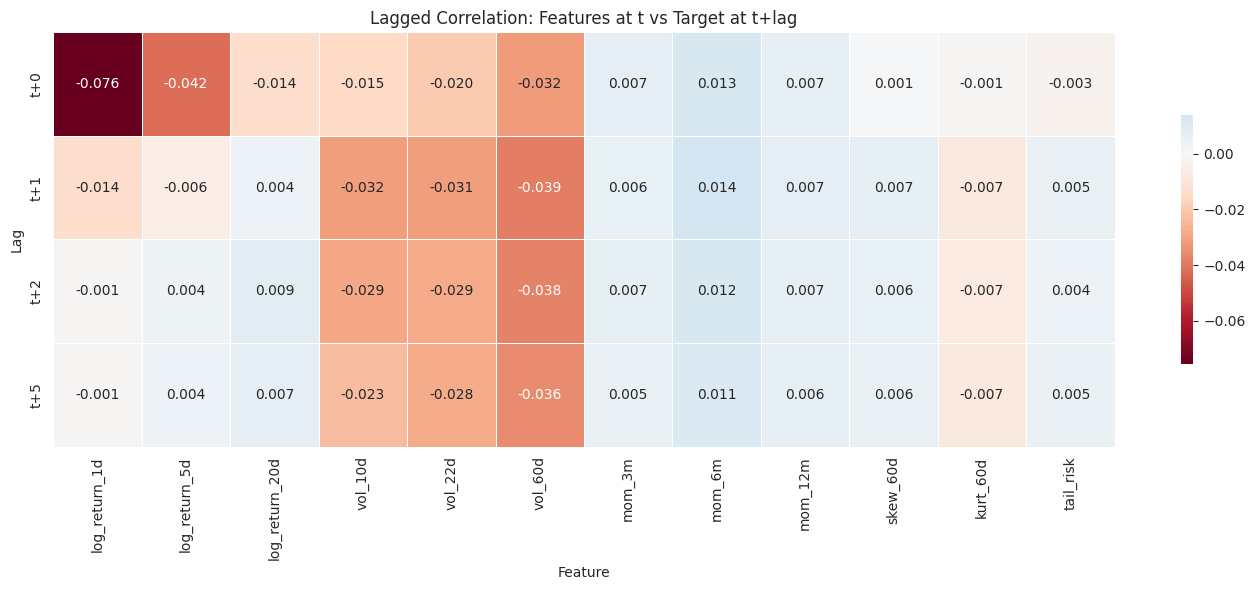


Lagged Correlation Summary:
  Strongest signal should be at t+1 for a clean forward target
  t+0 row (contemporaneous) max |r|: 0.0755
  t+1 row (target horizon)   max |r|: 0.0385


In [59]:
print("Lagged Correlation Matrix")

# Feature values at time t correlated against target at t+1, t+2 and t+5
# A clean construction shows the strongest predictive signal at t+1
# If t+0 dominates, look-ahead bias is present in the feature construction

lags_to_check = [0, 1, 2, 5]
lag_results   = {}

for lag in lags_to_check:
    lag_corrs = {}
    target_shifted = audit_clean['target_fwd_1d'].shift(-lag)

    for col in feature_cols:
        aligned = pd.concat(
            [audit_clean[col], target_shifted], axis=1
        ).dropna()
        if len(aligned) < 100:
            continue
        lag_corrs[col] = aligned.iloc[:, 0].corr(aligned.iloc[:, 1])

    lag_results[f't+{lag}'] = lag_corrs

lag_df = pd.DataFrame(lag_results).T

plt.figure(figsize=(14, 6))
sns.heatmap(
    lag_df,
    cmap='RdBu',
    center=0,
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    cbar_kws={'shrink': 0.6}
)
plt.title("Lagged Correlation: Features at t vs Target at t+lag")
plt.xlabel("Feature")
plt.ylabel("Lag")
plt.tight_layout()
plt.show()

print("\nLagged Correlation Summary:")
print(f"  Strongest signal should be at t+1 for a clean forward target")
print(f"  t+0 row (contemporaneous) max |r|: {lag_df.loc['t+0'].abs().max():.4f}")
print(f"  t+1 row (target horizon)   max |r|: {lag_df.loc['t+1'].abs().max():.4f}")

Rolling Leakage Check


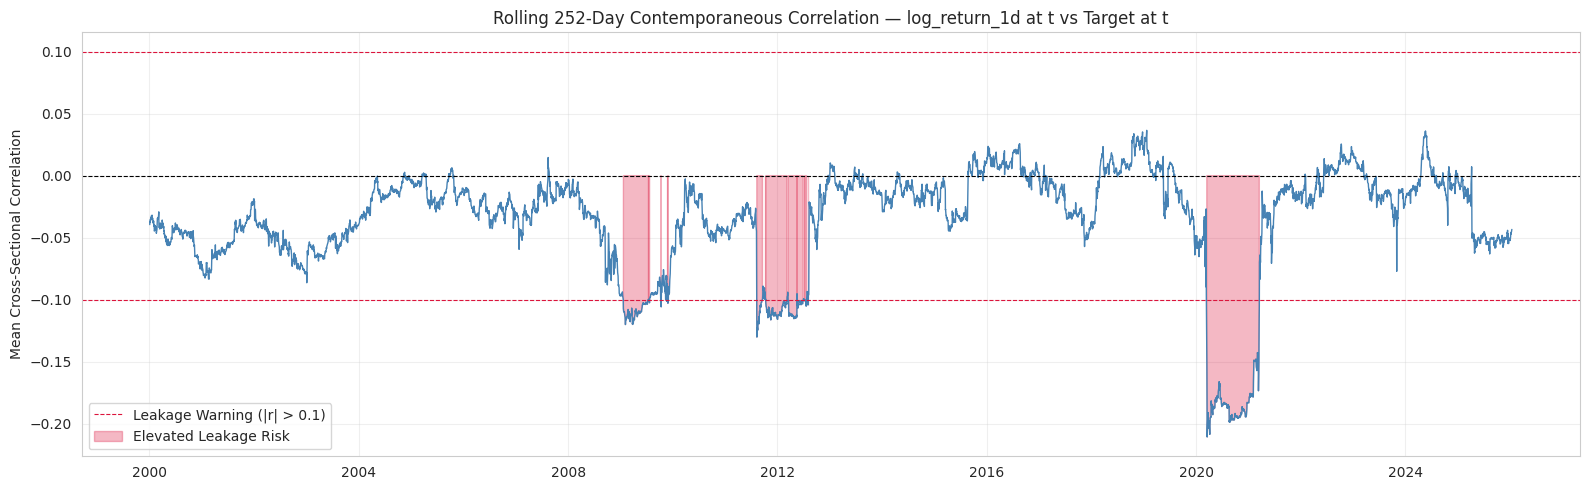


Rolling Leakage Summary (log_return_1d):
  Mean correlation over history:   -0.0355
  Max absolute correlation:        0.2107
  Periods above warning threshold: 603 days


In [60]:
print("Rolling Leakage Check")

# Run the contemporaneous correlation on a 252-day rolling window over time
# A stable near-zero line across all features confirms the pipeline is clean
# Spikes at specific dates indicate periods where data errors may have
# introduced look-ahead — worth cross-referencing with known corporate actions

# Vectorised approach: for each date window compute the mean cross-sectional
# correlation between log_return_1d at t and target_fwd_1d at t
# This avoids a slow day-by-day Python loop over the full date range

check_col = 'log_return_1d'

# Build aligned wide matrices for the feature and target
audit_pivot  = audit_df.pivot(index='Date', columns='Ticker', values=check_col)
target_pivot = audit_df.pivot(index='Date', columns='Ticker', values='target_fwd_1d')

# Align columns to common tickers
common_tickers = audit_pivot.columns.intersection(target_pivot.columns)
audit_pivot    = audit_pivot[common_tickers]
target_pivot   = target_pivot[common_tickers]

# Compute rolling cross-sectional correlation date by date using a vectorised window
window       = 252
rolling_dates = audit_pivot.index[window:]
rolling_corrs = []

for end_idx in range(window, len(audit_pivot)):
    feat_window   = audit_pivot.iloc[end_idx - window:end_idx]
    target_window = target_pivot.iloc[end_idx - window:end_idx]

    # Cross-sectional correlation: stack both windows and correlate ticker by ticker
    ticker_corrs = [
        feat_window[t].corr(target_window[t])
        for t in common_tickers
        if feat_window[t].notna().sum() > 30
    ]
    finite_corrs = [c for c in ticker_corrs if np.isfinite(c)]
    rolling_corrs.append(np.mean(finite_corrs) if finite_corrs else np.nan)

rolling_leakage = pd.Series(rolling_corrs, index=rolling_dates).dropna()

plt.figure(figsize=(16, 5))
plt.plot(rolling_leakage.index, rolling_leakage.values,
         color='steelblue', linewidth=1)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axhline(0.1, color='crimson', linewidth=0.8,
            linestyle='--', label='Leakage Warning (|r| > 0.1)')
plt.axhline(-0.1, color='crimson', linewidth=0.8, linestyle='--')
plt.fill_between(
    rolling_leakage.index,
    rolling_leakage.values,
    0,
    where=(rolling_leakage.abs() > 0.1),
    color='crimson', alpha=0.3, label='Elevated Leakage Risk'
)
plt.title(f"Rolling 252-Day Contemporaneous Correlation — {check_col} at t vs Target at t")
plt.ylabel("Mean Cross-Sectional Correlation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nRolling Leakage Summary ({check_col}):")
print(f"  Mean correlation over history:   {rolling_leakage.mean():.4f}")
print(f"  Max absolute correlation:        {rolling_leakage.abs().max():.4f}")
print(f"  Periods above warning threshold: {(rolling_leakage.abs() > 0.1).sum()} days")

# **Section 12 — Manifold Readiness**

In [61]:
print("Applying Robust Z-Score Normalisation")

# Replicate the robust_zscore function from stage3_engineer_features.py
# Applied per ticker via groupby transform to ensure each ticker's own
# rolling history is used — matching exactly what the pipeline produces

def robust_zscore_series(series: pd.Series, window: int = 252) -> pd.Series:
    """Rolling robust z-score using median and MAD (Huber, 1981)."""
    median = series.rolling(window=window).median()

    def calc_mad(x):
        return np.nanmedian(np.abs(x - np.nanmedian(x)))

    mad = series.rolling(window=window).apply(calc_mad, raw=True)
    return (series - median) / (1.4826 * mad + 1e-8)

# Build the normalised audit dataframe from the feature columns
normalised_audit = audit_df[['Date', 'Ticker'] + feature_cols].copy()

for col in feature_cols:
    normalised_audit[col] = (
        normalised_audit.groupby('Ticker', observed=True)[col]
        .transform(lambda x: robust_zscore_series(x, window=min(252, len(x))))
    )

# Select the cross-section date with the most complete normalised data
date_counts        = normalised_audit.dropna(subset=feature_cols)['Date'].value_counts()
cross_section_date = date_counts.idxmax()

cross_section_norm = normalised_audit[
    normalised_audit['Date'] == cross_section_date
].dropna(subset=feature_cols).copy()

print(f"\nNormalisation complete")
print(f"Cross-section date selected: {cross_section_date.date()}")
print(f"Tickers with complete normalised features: {len(cross_section_norm)}")

Applying Robust Z-Score Normalisation

Normalisation complete
Cross-section date selected: 2001-03-29
Tickers with complete normalised features: 30


Feature Norm Distribution Before and After Robust Z-Score


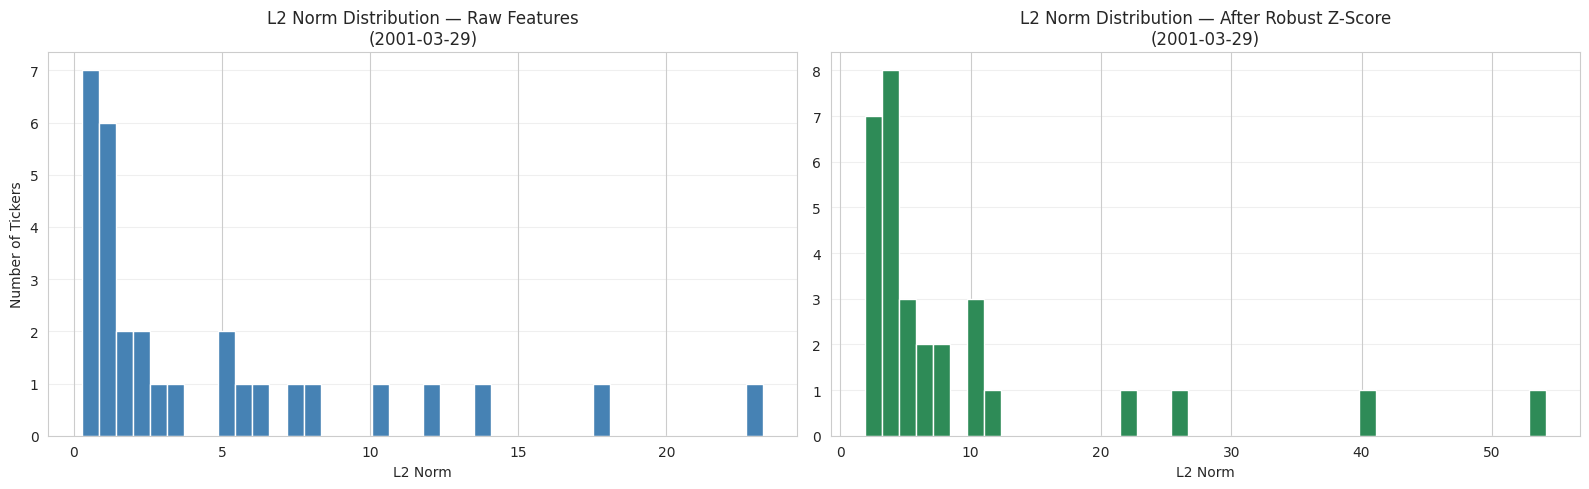


Cross-Section Date: 2001-03-29
Tickers in cross-section: 30

Raw Feature Norms:
  Mean:  4.6783
  Std:   5.6170
  Min:   0.2817
  Max:   23.2725

Normalised Feature Norms:
  Mean:  9.1321
  Std:   11.6626
  Min:   1.8843
  Max:   54.1570


In [62]:
print("Feature Norm Distribution Before and After Robust Z-Score")

# The robust_zscore function from stage3_engineer_features uses rolling median
# and MAD (Huber, 1981) rather than mean and standard deviation
# This prevents single extreme events from distorting the geometric embedding
# We verify that after normalisation, feature vector norms are finite and
# well-distributed — a prerequisite for stable hypersphere projection

if len(cross_section_norm) < 2:
    print("Insufficient tickers in cross-section — check normalisation cell output")
else:
    # Raw features at the cross-section date before normalisation
    cross_section_raw = audit_df[
        audit_df['Date'] == cross_section_date
    ].dropna(subset=feature_cols).copy()

    raw_matrix  = cross_section_raw[feature_cols].values.astype(np.float64)
    norm_matrix = cross_section_norm[feature_cols].values.astype(np.float64)

    raw_norms  = np.linalg.norm(raw_matrix, axis=1)
    norm_norms = np.linalg.norm(norm_matrix, axis=1)

    finite_raw  = raw_norms[np.isfinite(raw_norms)]
    finite_norm = norm_norms[np.isfinite(norm_norms)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].hist(finite_raw, bins=40, color='steelblue', edgecolor='white')
    axes[0].set_title(
        f"L2 Norm Distribution — Raw Features\n({cross_section_date.date()})"
    )
    axes[0].set_xlabel("L2 Norm")
    axes[0].set_ylabel("Number of Tickers")
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].hist(finite_norm, bins=40, color='seagreen', edgecolor='white')
    axes[1].set_title(
        f"L2 Norm Distribution — After Robust Z-Score\n({cross_section_date.date()})"
    )
    axes[1].set_xlabel("L2 Norm")
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nCross-Section Date: {cross_section_date.date()}")
    print(f"Tickers in cross-section: {len(cross_section_norm)}")
    print(f"\nRaw Feature Norms:")
    print(f"  Mean:  {finite_raw.mean():.4f}")
    print(f"  Std:   {finite_raw.std():.4f}")
    print(f"  Min:   {finite_raw.min():.4f}")
    print(f"  Max:   {finite_raw.max():.4f}")
    print(f"\nNormalised Feature Norms:")
    print(f"  Mean:  {finite_norm.mean():.4f}")
    print(f"  Std:   {finite_norm.std():.4f}")
    print(f"  Min:   {finite_norm.min():.4f}")
    print(f"  Max:   {finite_norm.max():.4f}")

Feature Distribution Heatmap


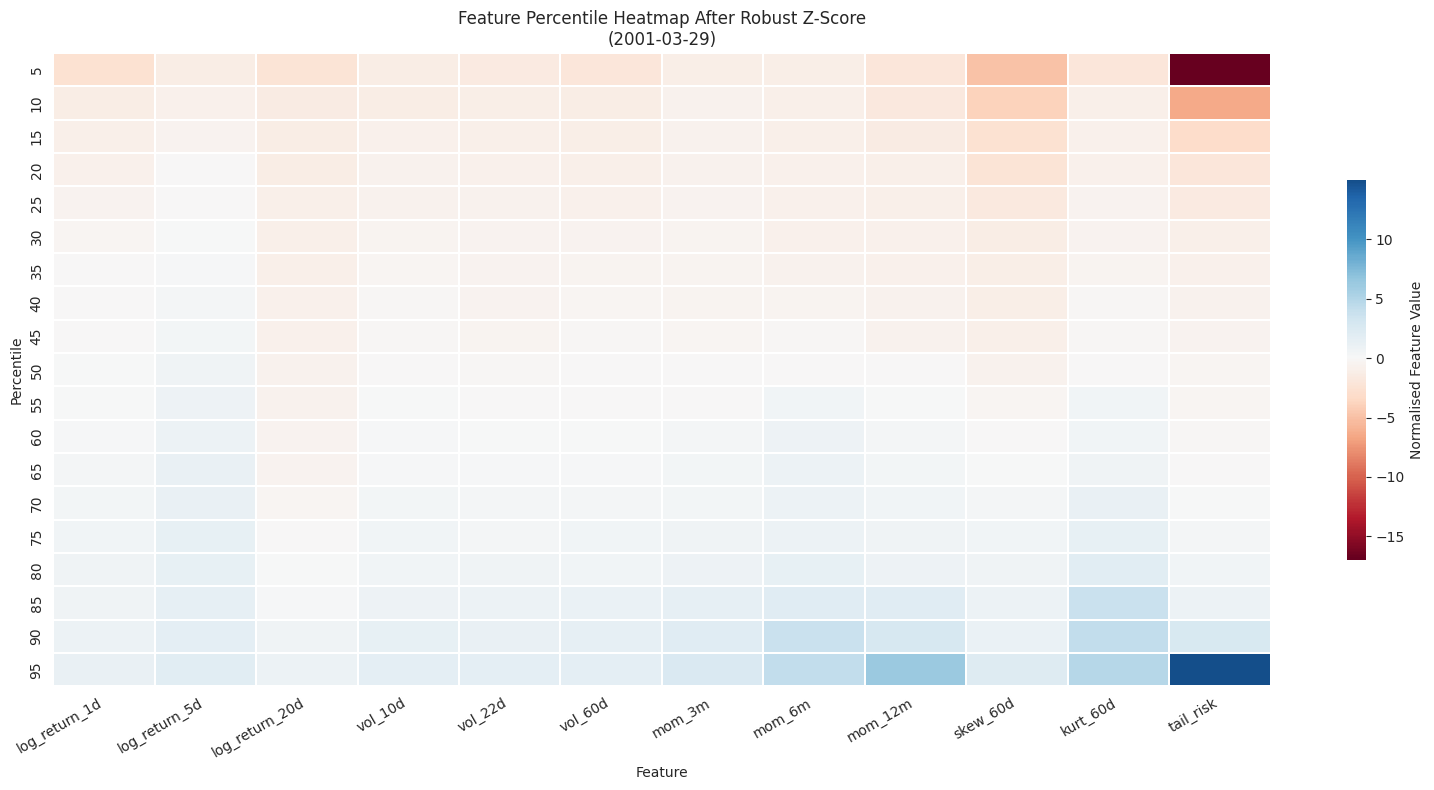


Normalised Feature Summary (post robust z-score):
  Feature                  Mean      Std      Min      Max
  log_return_1d          -0.213    1.437   -5.827    1.872
  log_return_5d           0.507    1.143   -3.016    2.164
  log_return_20d         -0.673    1.050   -3.764    1.553
  vol_10d                 0.255    1.846   -1.483    8.940
  vol_22d                 0.015    1.400   -2.135    5.680
  vol_60d                -0.125    1.142   -2.759    1.965
  mom_3m                  0.238    1.232   -1.840    3.441
  mom_6m                  0.540    1.805   -1.503    5.232
  mom_12m                 0.422    2.578   -2.583    8.405
  skew_60d               -0.823    2.145   -5.762    3.381
  kurt_60d                0.757    2.265   -2.881    6.888
  tail_risk              -0.139   13.855  -37.897   53.786


In [63]:
print("Feature Distribution Heatmap")

# On the representative cross-section date, show each feature's distribution
# across all tickers as a percentile heatmap
# Identifies skewed or outlier-dominated features before they reach the manifold
# After robust_zscore these should all be broadly comparable in scale

if len(cross_section_norm) < 2:
    print("Insufficient tickers in cross-section — check normalisation cell output")
else:
    norm_df = cross_section_norm[feature_cols].replace(
        [np.inf, -np.inf], np.nan
    ).dropna()

    percentiles  = np.arange(5, 100, 5)
    heatmap_data = pd.DataFrame(
        {col: np.nanpercentile(norm_df[col], percentiles) for col in feature_cols},
        index=percentiles
    )

    plt.figure(figsize=(16, 8))
    sns.heatmap(
        heatmap_data,
        cmap='RdBu',
        center=0,
        annot=False,
        linewidths=0.3,
        cbar_kws={'label': 'Normalised Feature Value', 'shrink': 0.6}
    )
    plt.title(
        f"Feature Percentile Heatmap After Robust Z-Score\n({cross_section_date.date()})"
    )
    plt.xlabel("Feature")
    plt.ylabel("Percentile")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    print("\nNormalised Feature Summary (post robust z-score):")
    print(f"  {'Feature':<20} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
    for col in feature_cols:
        col_data = norm_df[col].dropna()
        if len(col_data) == 0:
            continue
        print(f"  {col:<20} {col_data.mean():>8.3f} {col_data.std():>8.3f} "
              f"{col_data.min():>8.3f} {col_data.max():>8.3f}")

Hypersphere Projection Sanity Check

Cross-Section Date: 2001-03-29
Tickers with complete normalised features: 30
Tickers projected:             30
Tickers excluded (zero norm):  0


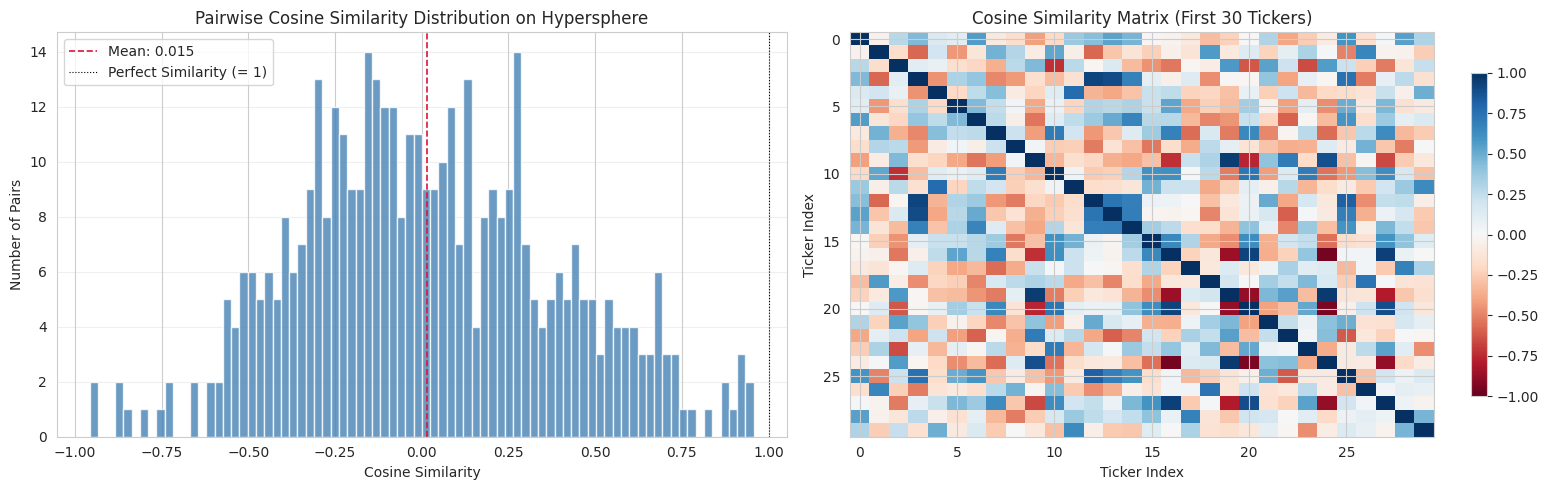


Unique Pairs Assessed: 435

Cosine Similarity Statistics:
  Mean:    0.0155
  Std Dev: 0.3720
  Min:     -0.9565
  Max:     0.9570

  Pairs with similarity > 0.9 (near-identical): 5 (1.15%)
  Pairs with similarity < 0.0 (opposing):       225 (51.72%)


In [64]:
print("Hypersphere Projection Sanity Check")

# Project the normalised feature matrix onto the unit hypersphere
# by dividing each row vector by its L2 norm
# Then compute pairwise cosine similarities to verify angular separation exists
# If all stocks collapse to the same point the manifold has no discriminative power
# If similarities are broadly distributed the geometric layer has structure to learn

def robust_zscore_series(series: pd.Series, window: int = 252) -> pd.Series:
    """Rolling robust z-score using median and MAD (Huber, 1981)."""
    median = series.rolling(window=window).median()

    def calc_mad(x):
        return np.nanmedian(np.abs(x - np.nanmedian(x)))

    mad = series.rolling(window=window).apply(calc_mad, raw=True)
    return (series - median) / (1.4826 * mad + 1e-8)

# Apply robust z-score to each feature column across the full audit_df history
# then extract the cross-section at the representative date
# This ensures rolling windows are properly populated before we slice
normalised_audit = audit_df[['Date', 'Ticker'] + feature_cols].copy()

for col in feature_cols:
    normalised_audit[col] = (
        normalised_audit.groupby('Ticker', observed=True)[col]
        .transform(lambda x: robust_zscore_series(x, window=min(252, len(x))))
    )

# Select the cross-section date with the most complete data coverage
date_counts = normalised_audit.dropna(subset=feature_cols)['Date'].value_counts()
cross_section_date = date_counts.idxmax()

cross_section_norm = normalised_audit[
    normalised_audit['Date'] == cross_section_date
].dropna(subset=feature_cols).copy()

print(f"\nCross-Section Date: {cross_section_date.date()}")
print(f"Tickers with complete normalised features: {len(cross_section_norm)}")

if len(cross_section_norm) < 2:
    print("Insufficient tickers for projection — try a different cross-section date")
else:
    # Build the normalised feature matrix
    feature_matrix = cross_section_norm[feature_cols].values.astype(np.float64)

    # Compute L2 norms and identify valid rows
    norms      = np.linalg.norm(feature_matrix, axis=1)
    valid_mask = np.isfinite(norms) & (norms > 1e-8)

    valid_features = feature_matrix[valid_mask]
    valid_norms    = norms[valid_mask]

    print(f"Tickers projected:             {valid_mask.sum()}")
    print(f"Tickers excluded (zero norm):  {(~valid_mask).sum()}")

    if valid_mask.sum() < 2:
        print("Not enough valid tickers after norm filtering")
    else:
        # Project to unit hypersphere
        projected = valid_features / valid_norms[:, np.newaxis]

        # Pairwise cosine similarities — limit to 200 tickers for tractability
        n_sample    = min(200, len(projected))
        sample_proj = projected[:n_sample]
        cosine_sim  = sample_proj @ sample_proj.T

        # Extract upper triangle (unique pairs only)
        upper_idx    = np.triu_indices(n_sample, k=1)
        similarities = cosine_sim[upper_idx]
        similarities = similarities[np.isfinite(similarities)]

        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        # Distribution of cosine similarities
        axes[0].hist(similarities, bins=80, color='steelblue',
                     edgecolor='white', alpha=0.8)
        axes[0].axvline(
            similarities.mean(), color='crimson', linestyle='--',
            linewidth=1.2, label=f'Mean: {similarities.mean():.3f}'
        )
        axes[0].axvline(1.0, color='black', linewidth=0.8, linestyle=':',
                        label='Perfect Similarity (= 1)')
        axes[0].set_title("Pairwise Cosine Similarity Distribution on Hypersphere")
        axes[0].set_xlabel("Cosine Similarity")
        axes[0].set_ylabel("Number of Pairs")
        axes[0].legend()
        axes[0].grid(axis='y', alpha=0.3)

        # Cosine similarity matrix heatmap
        im = axes[1].imshow(cosine_sim, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
        axes[1].set_title(f"Cosine Similarity Matrix (First {n_sample} Tickers)")
        axes[1].set_xlabel("Ticker Index")
        axes[1].set_ylabel("Ticker Index")
        plt.colorbar(im, ax=axes[1], shrink=0.8)

        plt.tight_layout()
        plt.show()

        print(f"\nUnique Pairs Assessed: {len(similarities):,}")
        print(f"\nCosine Similarity Statistics:")
        print(f"  Mean:    {similarities.mean():.4f}")
        print(f"  Std Dev: {similarities.std():.4f}")
        print(f"  Min:     {similarities.min():.4f}")
        print(f"  Max:     {similarities.max():.4f}")
        print(f"\n  Pairs with similarity > 0.9 (near-identical): "
              f"{(similarities > 0.9).sum():,} ({(similarities > 0.9).mean():.2%})")
        print(f"  Pairs with similarity < 0.0 (opposing):       "
              f"{(similarities < 0.0).sum():,} ({(similarities < 0.0).mean():.2%})")